In [1]:
import mplhep as hep
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot as ur

from utils.labels import (
    luminosity
)

In [2]:
input_file = "../root_io/tuples/BDT_score/ggH/BFull_SNottH/Data_2024_BFull_SNottH.root"

In [3]:
with ur.open(input_file) as file:
    print(file.keys())

['tree_output;9', 'tree_output;8', 'tree_output;7']


In [4]:
out_tree = ur.open(input_file+":tree_output")
out_tree.keys()

['gen_weight',
 'pileup_weight',
 'pileup_weight_up',
 'pileup_weight_down',
 'scale_factor',
 'weight',
 'weight_no_lumi',
 'rho',
 'PV',
 'n_SoftJet_pt2',
 'n_SoftJet_pt5',
 'n_SoftJet_pt10',
 'HT',
 'HT_pt2',
 'HT_pt5',
 'HT_pt10',
 'is_ggH_category',
 'is_VBF_category',
 'diMuon_mass',
 'diMuon_bsConstrainedMass',
 'diMuon_pt',
 'diMuon_bsConstrainedPt',
 'diMuon_phi',
 'diMuon_eta',
 'diMuon_rapidity',
 'PuppiMET_phi',
 'PuppiMET_pt',
 'PuppiMET_sumEt',
 'mu1_pt_mass_ratio',
 'mu2_pt_mass_ratio',
 'mu1_bsConstrainedPt_mass_ratio',
 'mu2_bsConstrainedPt_mass_ratio',
 'mu1_eta',
 'mu2_eta',
 'mu1_pt',
 'mu2_pt',
 'mu1_bsConstrainedPt',
 'mu2_bsConstrainedPt',
 'mu1_ptErr',
 'mu2_ptErr',
 'mu1_bsConstrainedPtErr',
 'mu2_bsConstrainedPtErr',
 'phi_CS',
 'cos_theta_CS',
 'relative_diMuon_mass_error',
 'relative_diMuon_bsConstrainedMass_error',
 'n_jet',
 'n_bjet',
 'n_bjet_Loose',
 'leading_jet_pt',
 'leading_jet_eta',
 'subleading_jet_pt',
 'subleading_jet_eta',
 'diJet_mass',
 'delta

In [5]:
diMuon_mass_bsC = out_tree["diMuon_bsConstrainedMass"].array(library='np')

/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-a3a65cbc18c6a98e06451d4329e3ea47/lib/python3.9/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-a3a65cbc18c6a98e06451d4329e3ea47/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


(exptext: Custom Text(0.0, 1, 'CMS'),
 expsuffix: Custom Text(0.0, 1.005, 'Simulation Preliminary'))

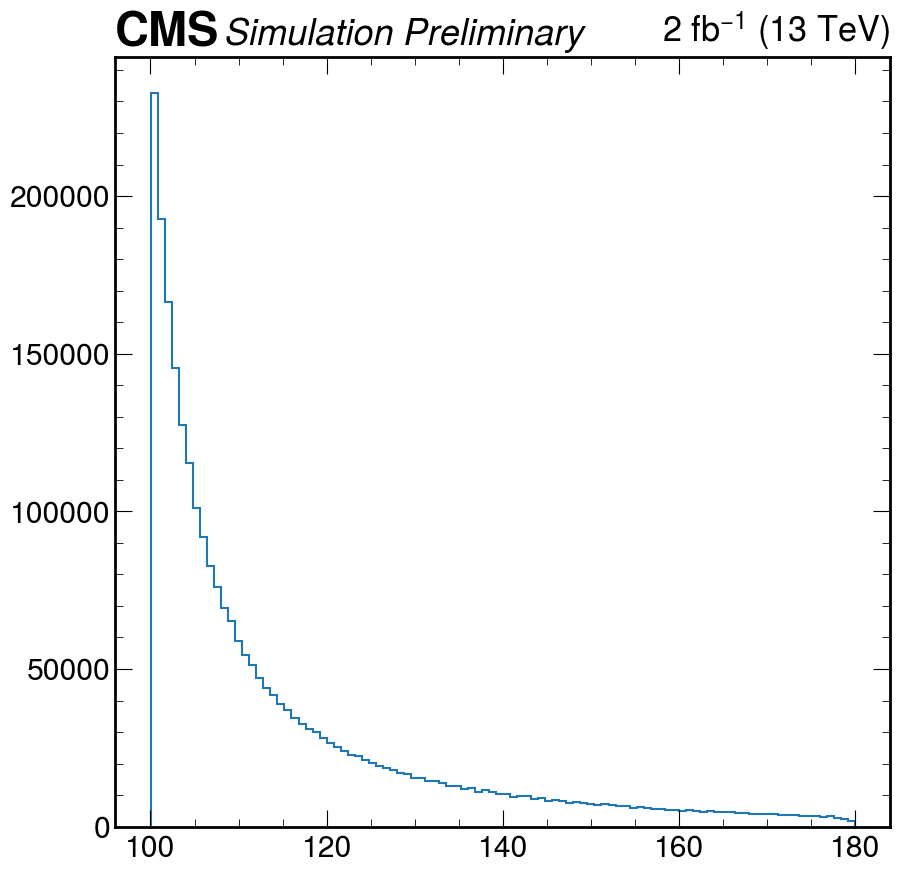

In [6]:
hep.style.use("CMS")

counts, bins = np.histogram(diMuon_mass_bsC, bins=100)

#Create a plot
fig, ax = plt.subplots()

# Plot a pre-binned histogram
hep.histplot(counts, bins=bins, ax=ax, label="hi")
# Add appropriate labels
hep.cms.label("Preliminary", data=False, lumi=2, com=13) # ax can be implicit
# mh.mpl_magic(soft_fail=True)  # Autofit label - not needed

In [7]:
BDT_ggH = out_tree["BDT_ggH"].array(library='np')
leading_jet_eta = out_tree["leading_jet_eta"].array(library='np')

In [8]:
mu1_pt_mass_ratio = out_tree["leading_jet_pt"].array(library='np')
mu1_pt_mass_ratio

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

Text(0, 1, 'BDT score')

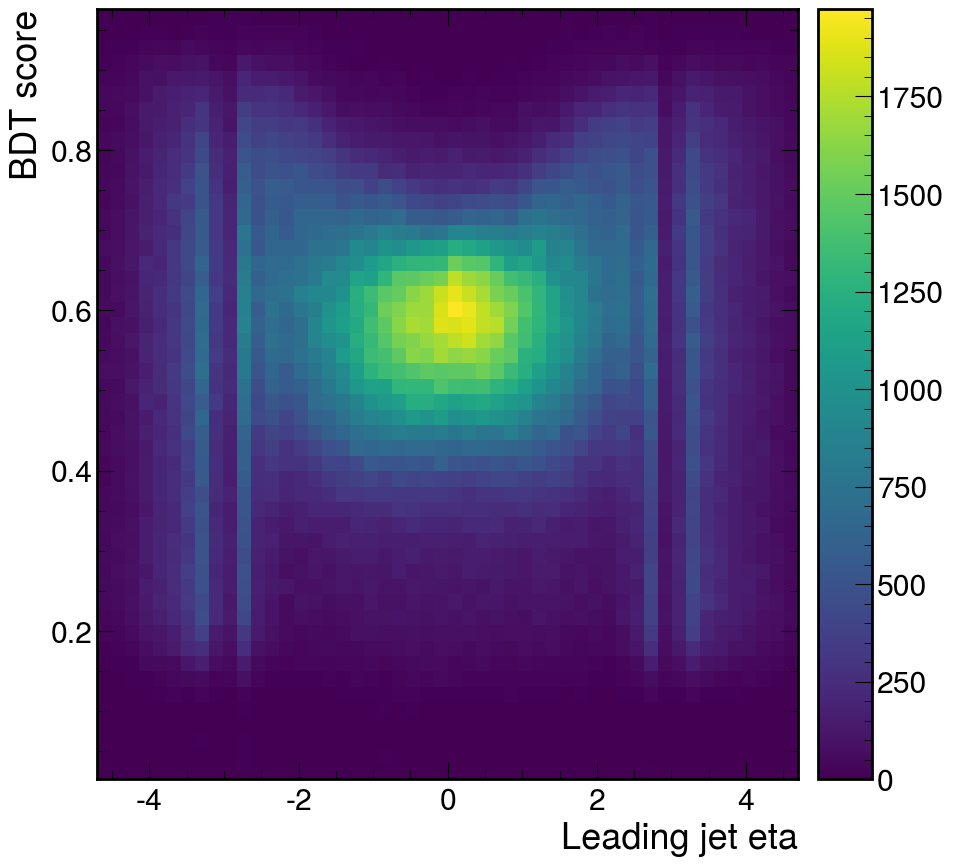

In [9]:
mask = leading_jet_eta != 0
H, xedges, yedges = np.histogram2d(leading_jet_eta[mask], BDT_ggH[mask], bins=50)

fig, ax = plt.subplots()
hep.hist2dplot(H, xedges, yedges, ax=ax, cbar=True)
ax.set_xlabel('Leading jet eta')
ax.set_ylabel('BDT score')

In [10]:
def plot_BDTscore_vs_jetEta(inputFile, isVBF=False):
    print(inputFile)
    out_tree = ur.open(inputFile+":tree_output")
    if(not isVBF):
        BDT_ggH = out_tree["BDT_ggH"].array(library='np')
    else:
        BDT_ggH = out_tree["BDT_VBF"].array(library='np')
    leading_jet_eta = out_tree["leading_jet_eta"].array(library='np')
    subleading_jet_eta = out_tree["subleading_jet_eta"].array(library='np')
    
    mask = (leading_jet_eta != 0) & (subleading_jet_eta != 0)
    H, xedges, yedges = np.histogram2d(leading_jet_eta[mask], BDT_ggH[mask], bins=50)

    fig, ax = plt.subplots()
    hep.hist2dplot(H, xedges, yedges, ax=ax, cbar=True)
    ax.set_xlabel('Leading jet eta')
    ax.set_ylabel('BDT score')
    ax.set_title('BDT signal strength across eta')
    plt.show()

../root_io/tuples/BDT_score/VBF/BFull_SNottH/VBF_2024_BFull_SNottH.root


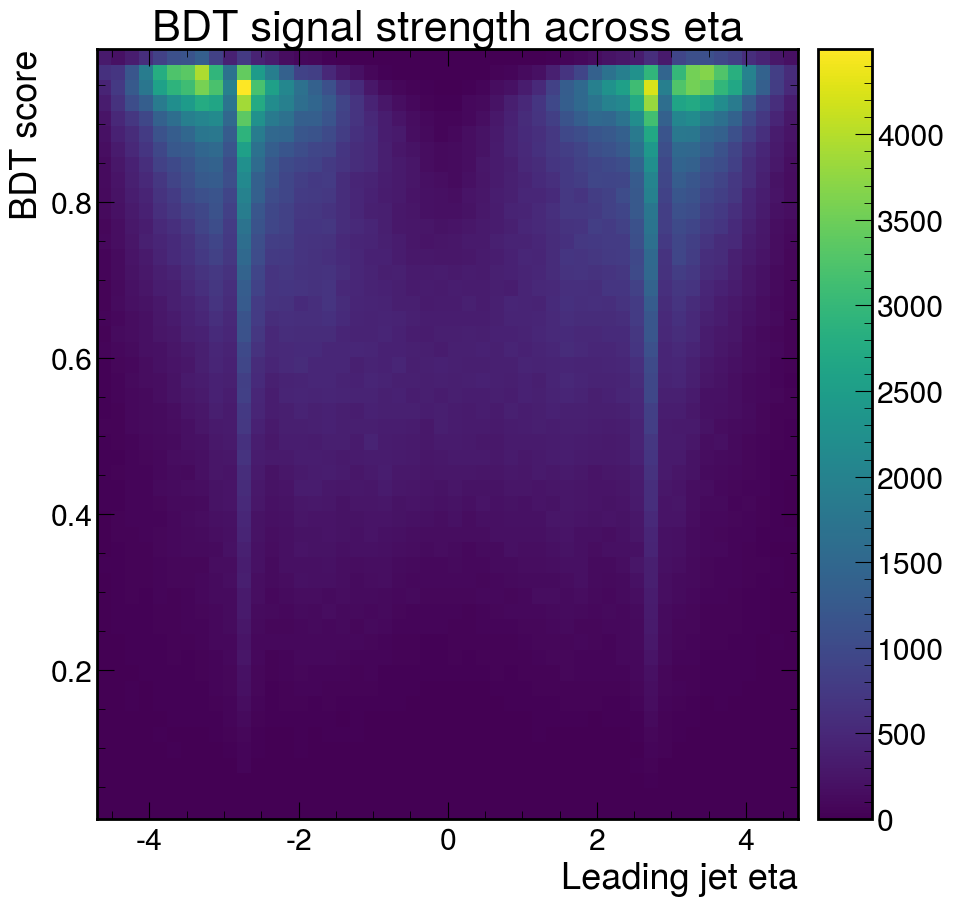

In [11]:
#plot_BDTscore_vs_jetEta("../root_io/tuples/BDT_score/ggH/BFull_SNottH/ggH_2024_BFull_SNottH.root")
plot_BDTscore_vs_jetEta("../root_io/tuples/BDT_score/VBF/BFull_SNottH/VBF_2024_BFull_SNottH.root", True)

[0.0, 0.19152000000000016, 0.5472000000000005, 0.8550000000000006, 1.0]


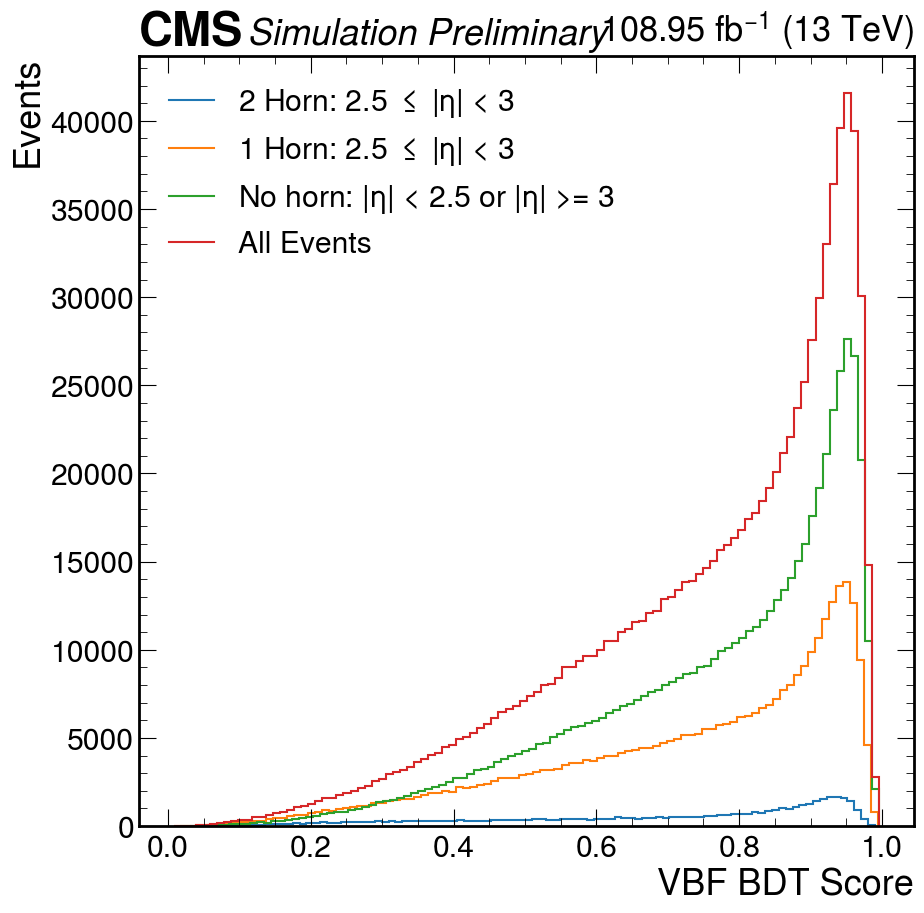

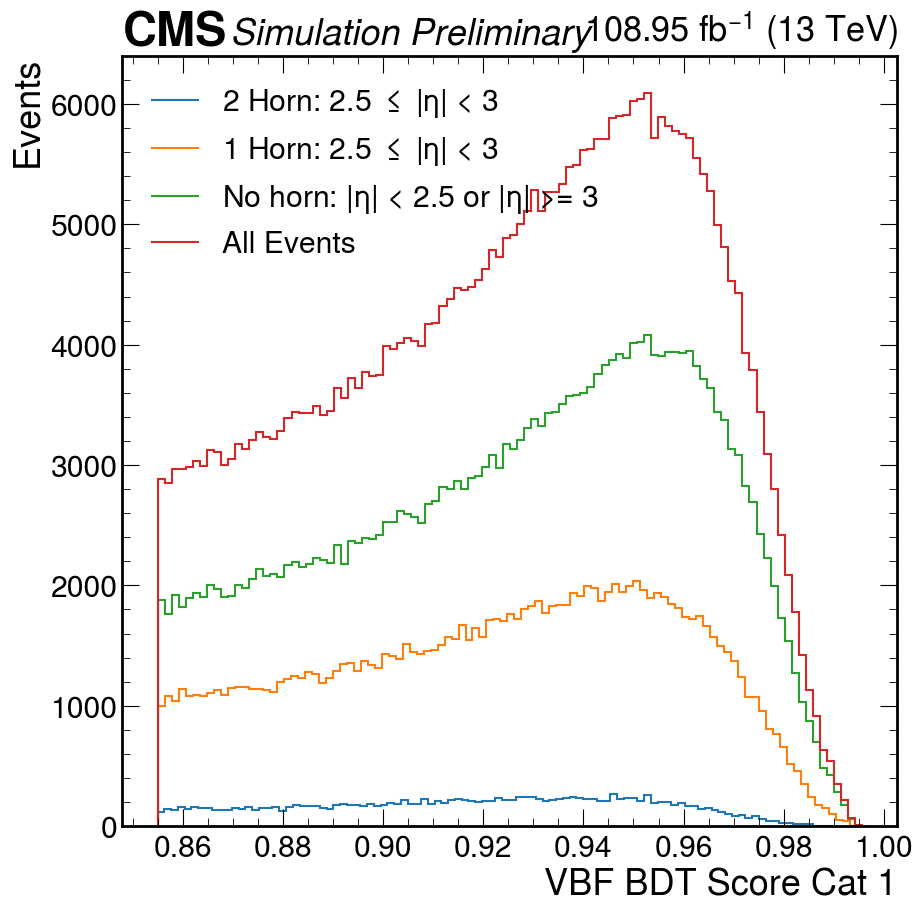

In [12]:
input_file = "../root_io/tuples/BDT_score/VBF/BFull_SNottH/VBF_2024_BFull_SNottH.root"
out_tree = ur.open(input_file+":tree_output")
BDT_VBF = out_tree["BDT_VBF"].array(library='np')
leading_jet_eta = out_tree["leading_jet_eta"].array(library='np')
subleading_jet_eta = out_tree["subleading_jet_eta"].array(library='np')
leading_jet_pt = out_tree["leading_jet_pt"].array(library='np')
subleading_jet_pt = out_tree["subleading_jet_pt"].array(library='np')

horn_mask = (np.abs(leading_jet_eta) >= 2.5) & (np.abs(leading_jet_eta) < 3) & (np.abs(subleading_jet_eta) >= 2.5) & (np.abs(subleading_jet_eta) < 3)
eitherHorn_mask = ((np.abs(leading_jet_eta) >= 2.5) & (np.abs(leading_jet_eta) < 3)) | ((np.abs(subleading_jet_eta) >= 2.5) & (np.abs(subleading_jet_eta) < 3))
jet_mask = leading_jet_eta != 0

bdt_selections = {
    "ggH": {
        "BFull_SNottH": [0.0, 0.19730769230769193, 0.4384615384615378, 1.0],

    },
    "VBF": {"BFull_SNottH":[0.0, 0.19152000000000016, 0.5472000000000005, 0.8550000000000006, 1.0],
    },
}

print(bdt_selections["VBF"]["BFull_SNottH"])

countsHorn, binsHorn = np.histogram(BDT_VBF[horn_mask], bins=100)
countsEitherHorn, binsEitherHorn = np.histogram(BDT_VBF[eitherHorn_mask], bins=100)
countsNotHorn, binsNotHorn = np.histogram(BDT_VBF[~eitherHorn_mask], bins=100)
countsAll, binsAll = np.histogram(BDT_VBF[jet_mask], bins=100)

countsHorncat1, binsHorncat1 = np.histogram(BDT_VBF[horn_mask][BDT_VBF[horn_mask] > bdt_selections["VBF"]["BFull_SNottH"][-2]], bins=100)
countsEitherHorncat1, binsEitherHorncat1 = np.histogram(BDT_VBF[eitherHorn_mask][BDT_VBF[eitherHorn_mask] > bdt_selections["VBF"]["BFull_SNottH"][-2]], bins=100)
countsNotHorncat1, binsNotHorncat1 = np.histogram(BDT_VBF[~eitherHorn_mask][BDT_VBF[~eitherHorn_mask] > bdt_selections["VBF"]["BFull_SNottH"][-2]], bins=100)
countsAllcat1, binsAllcat1 = np.histogram(BDT_VBF[jet_mask][BDT_VBF[jet_mask] > bdt_selections["VBF"]["BFull_SNottH"][-2]], bins=100)


#Create a plot
fig, ax = plt.subplots()

# Plot a pre-binned histogram
hep.histplot(countsHorn, bins=binsHorn, ax=ax, label="2 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsEitherHorn, bins=binsEitherHorn, ax=ax, label="1 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsNotHorn, bins=binsNotHorn, ax=ax, label="No horn: |$\eta$| < 2.5 or |$\eta$| >= 3")
hep.histplot(countsAll, bins=binsAll, ax=ax, label="All Events")
# Add appropriate labels
hep.cms.label("Preliminary", data=False, lumi=108.95, com=13) # ax can be implicit
ax.legend()
#hep.mpl_magic()  # Autofit label - not needed

ax.set_xlabel('VBF BDT Score')
ax.set_ylabel('Events')
#ax.set_title('Jet eta horn BDT score comparison')
plt.savefig('../plots/BDT_score/VBF_BDT_score_all.png')

plt.show()

fig, ax = plt.subplots()

# Plot a pre-binned histogram
hep.histplot(countsHorncat1, bins=binsHorncat1, ax=ax, label="2 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsEitherHorncat1, bins=binsEitherHorncat1, ax=ax, label="1 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsNotHorncat1, bins=binsNotHorncat1, ax=ax, label="No horn: |$\eta$| < 2.5 or |$\eta$| >= 3")
hep.histplot(countsAllcat1, bins=binsAllcat1, ax=ax, label="All Events")
# Add appropriate labels
hep.cms.label("Preliminary", data=False, lumi=108.95, com=13) # ax can be implicit
ax.legend()
#hep.mpl_magic()  # Autofit label - not needed

ax.set_xlabel('VBF BDT Score Cat 1')
ax.set_ylabel('Events')
#ax.set_title('Jet eta horn BDT score comparison')
plt.savefig('../plots/BDT_score/VBF_BDT_score_cat1.png')


In [13]:
countsHorn_norm = countsHorn / countsHorn.sum()
countsEitherHorn_norm = countsEitherHorn / countsEitherHorn.sum()
countsNotHorn_norm = countsNotHorn / countsNotHorn.sum()
countsAll_norm = countsAll / countsAll.sum()

print("------------------ VBF ------------------")
print("Total number of events: {}".format(countsAll.sum()))
print("Events with a horn jet: {} | {:.2f}%".format(countsEitherHorn.sum(), countsEitherHorn.sum()/countsAll.sum() *100))
print("Events with both horn jets: {} | {:.2f}%".format(countsHorn.sum(), countsHorn.sum()/countsAll.sum() *100))
print("Events with only 1 horn jet: {} | {:.2f}%".format(countsEitherHorn.sum() - countsHorn.sum(), (countsEitherHorn.sum() - countsHorn.sum())/countsAll.sum() *100))
print("Events with no horn jets: {} | {:.2f}%".format(countsNotHorn.sum(), countsNotHorn.sum()/countsAll.sum() *100))

print("\n------------------ VBF cat1 ------------------")

countsHorncat1_norm = countsHorncat1 / countsHorncat1.sum()
countsEitherHorncat1_norm = countsEitherHorncat1 / countsEitherHorncat1.sum()
countsNotHorncat1_norm = countsNotHorncat1 / countsNotHorncat1.sum()
countsAllcat1_norm = countsAllcat1 / countsAllcat1.sum()

print("Total number of events cat1: {}".format(countsAllcat1.sum()))
print("Events with a horn jet cat1: {} | {:.2f}%".format(countsEitherHorncat1.sum(), countsEitherHorncat1.sum()/countsAllcat1.sum() *100))
print("Events with both horn jets cat1: {} | {:.2f}%".format(countsHorncat1.sum(), countsHorncat1.sum()/countsAllcat1.sum() *100))
print("Events with only 1 horn jet cat1: {} | {:.2f}%".format(countsEitherHorncat1.sum() - countsHorncat1.sum(), (countsEitherHorncat1.sum() - countsHorncat1.sum())/countsAllcat1.sum() *100))
print("Events with no horn jet cat1s: {} | {:.2f}%".format(countsNotHorncat1.sum(), countsNotHorncat1.sum()/countsAllcat1.sum() *100))



------------------ VBF ------------------
Total number of events: 968992
Events with a horn jet: 361045 | 37.26%
Events with both horn jets: 45167 | 4.66%
Events with only 1 horn jet: 315878 | 32.60%
Events with no horn jets: 607947 | 62.74%

------------------ VBF cat1 ------------------
Total number of events cat1: 392558
Events with a horn jet cat1: 134376 | 34.23%
Events with both horn jets cat1: 16304 | 4.15%
Events with only 1 horn jet cat1: 118072 | 30.08%
Events with no horn jet cat1s: 258182 | 65.77%


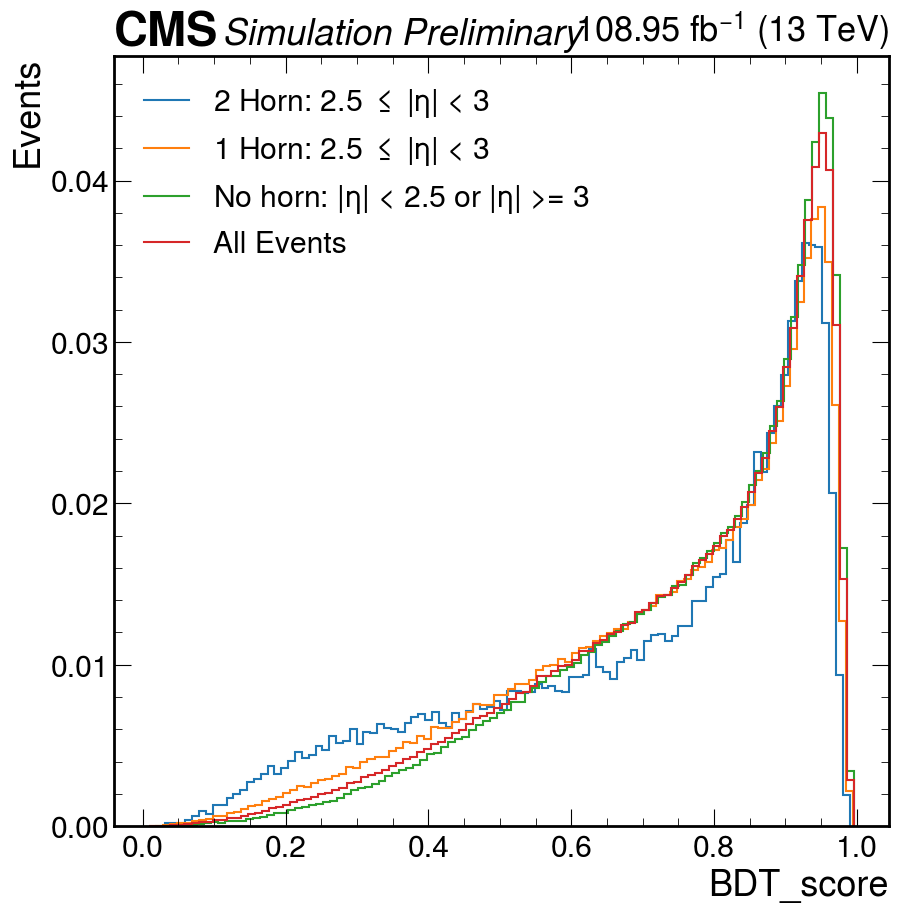

In [14]:
#Create a plot
fig, ax = plt.subplots()

# Plot a pre-binned histogram
hep.histplot(countsHorn_norm, bins=binsHorn, ax=ax, label="2 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsEitherHorn_norm, bins=binsEitherHorn, ax=ax, label="1 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsNotHorn_norm, bins=binsNotHorn, ax=ax, label="No horn: |$\eta$| < 2.5 or |$\eta$| >= 3")
hep.histplot(countsAll_norm, bins=binsAll, ax=ax, label="All Events")
# Add appropriate labels

hep.cms.label("Preliminary", data=False, lumi=108.95, com=13) # ax can be implicit
ax.legend()
#hep.mpl_magic()  # Autofit label - not needed

ax.set_xlabel('BDT_score')
ax.set_ylabel('Events')
#ax.set_title('Jet eta horn BDT score comparison')
plt.show()

[0.0, 0.19152000000000016, 0.5472000000000005, 0.8550000000000006, 1.0]


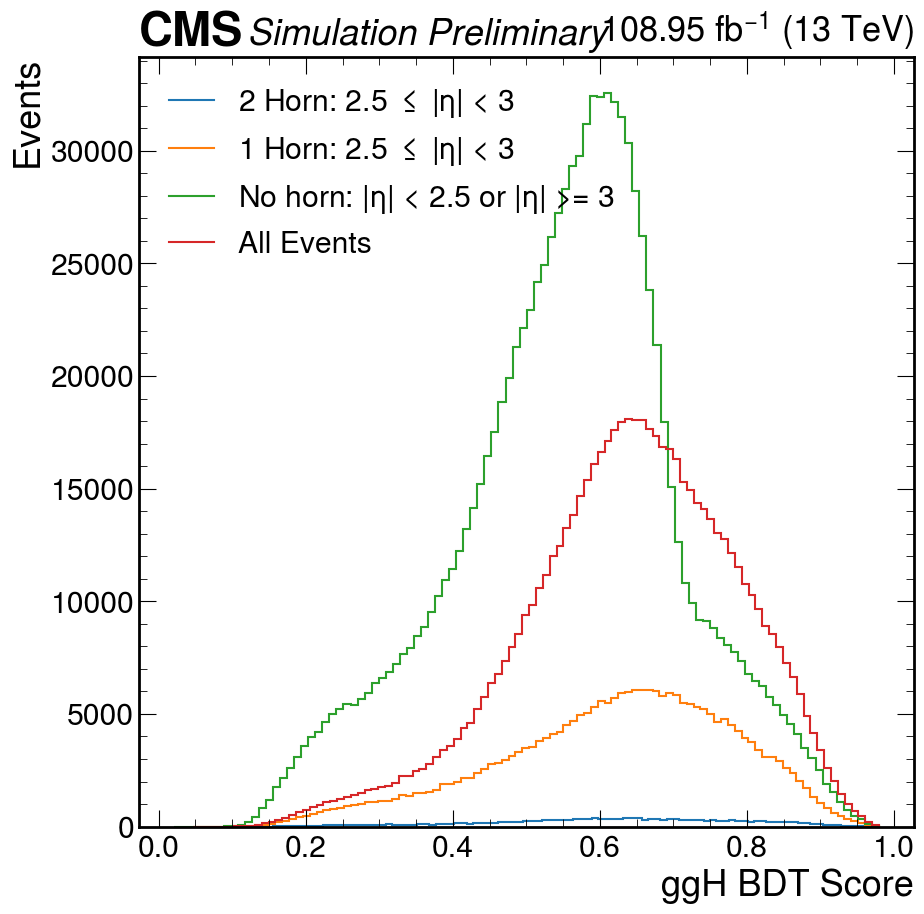

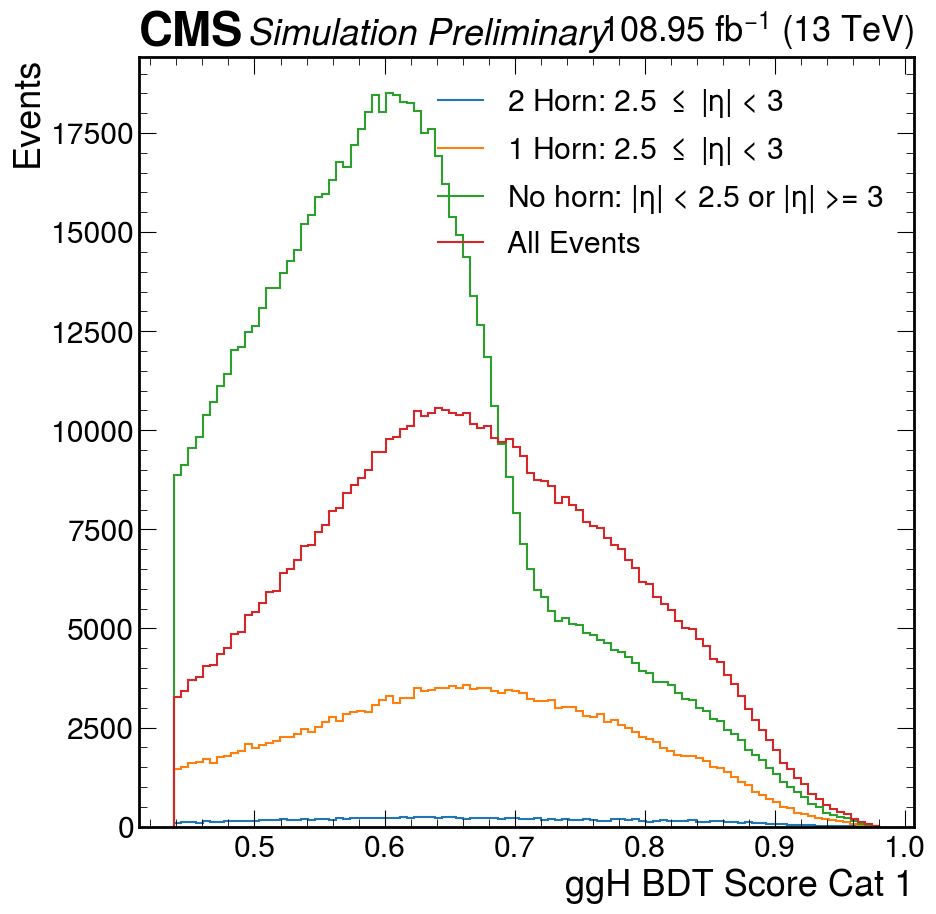

In [15]:
input_file = "../root_io/tuples/BDT_score/ggH/BFull_SNottH/ggH_2024_BFull_SNottH.root"
out_tree = ur.open(input_file+":tree_output")
BDT_ggH = out_tree["BDT_ggH"].array(library='np')
leading_jet_eta = out_tree["leading_jet_eta"].array(library='np')
subleading_jet_eta = out_tree["subleading_jet_eta"].array(library='np')
leading_jet_pt = out_tree["leading_jet_pt"].array(library='np')
subleading_jet_pt = out_tree["subleading_jet_pt"].array(library='np')

horn_mask = (np.abs(leading_jet_eta) >= 2.5) & (np.abs(leading_jet_eta) < 3) & (np.abs(subleading_jet_eta) >= 2.5) & (np.abs(subleading_jet_eta) < 3)
eitherHorn_mask = ((np.abs(leading_jet_eta) >= 2.5) & (np.abs(leading_jet_eta) < 3)) | ((np.abs(subleading_jet_eta) >= 2.5) & (np.abs(subleading_jet_eta) < 3))
jet_mask = leading_jet_eta != 0

bdt_selections = {
    "ggH": {
        "BFull_SNottH": [0.0, 0.19730769230769193, 0.4384615384615378, 1.0],

    },
    "VBF": {"BFull_SNottH":[0.0, 0.19152000000000016, 0.5472000000000005, 0.8550000000000006, 1.0],
    },
}

print(bdt_selections["VBF"]["BFull_SNottH"])

countsHorn, binsHorn = np.histogram(BDT_ggH[horn_mask], bins=100)
countsEitherHorn, binsEitherHorn = np.histogram(BDT_ggH[eitherHorn_mask], bins=100)
countsNotHorn, binsNotHorn = np.histogram(BDT_ggH[~eitherHorn_mask], bins=100)
countsAll, binsAll = np.histogram(BDT_ggH[jet_mask], bins=100)

countsHorncat1, binsHorncat1 = np.histogram(BDT_ggH[horn_mask][BDT_ggH[horn_mask] > bdt_selections["ggH"]["BFull_SNottH"][-2]], bins=100)
countsEitherHorncat1, binsEitherHorncat1 = np.histogram(BDT_ggH[eitherHorn_mask][BDT_ggH[eitherHorn_mask] > bdt_selections["ggH"]["BFull_SNottH"][-2]], bins=100)
countsNotHorncat1, binsNotHorncat1 = np.histogram(BDT_ggH[~eitherHorn_mask][BDT_ggH[~eitherHorn_mask] > bdt_selections["ggH"]["BFull_SNottH"][-2]], bins=100)
countsAllcat1, binsAllcat1 = np.histogram(BDT_ggH[jet_mask][BDT_ggH[jet_mask] > bdt_selections["ggH"]["BFull_SNottH"][-2]], bins=100)


#Create a plot
fig, ax = plt.subplots()

# Plot a pre-binned histogram
hep.histplot(countsHorn, bins=binsHorn, ax=ax, label="2 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsEitherHorn, bins=binsEitherHorn, ax=ax, label="1 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsNotHorn, bins=binsNotHorn, ax=ax, label="No horn: |$\eta$| < 2.5 or |$\eta$| >= 3")
hep.histplot(countsAll, bins=binsAll, ax=ax, label="All Events")
# Add appropriate labels
hep.cms.label("Preliminary", data=False, lumi=108.95, com=13) # ax can be implicit
ax.legend()
#hep.mpl_magic()  # Autofit label - not needed

ax.set_xlabel('ggH BDT Score')
ax.set_ylabel('Events')
#ax.set_title('Jet eta horn BDT score comparison')
plt.savefig('../plots/BDT_score/ggH_BDT_score_all.png')

plt.show()

fig, ax = plt.subplots()

# Plot a pre-binned histogram
hep.histplot(countsHorncat1, bins=binsHorncat1, ax=ax, label="2 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsEitherHorncat1, bins=binsEitherHorncat1, ax=ax, label="1 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsNotHorncat1, bins=binsNotHorncat1, ax=ax, label="No horn: |$\eta$| < 2.5 or |$\eta$| >= 3")
hep.histplot(countsAllcat1, bins=binsAllcat1, ax=ax, label="All Events")
# Add appropriate labels
hep.cms.label("Preliminary", data=False, lumi=108.95, com=13) # ax can be implicit
ax.legend()
#hep.mpl_magic()  # Autofit label - not needed

ax.set_xlabel('ggH BDT Score Cat 1')
ax.set_ylabel('Events')
#ax.set_title('Jet eta horn BDT score comparison')
plt.savefig('../plots/BDT_score/ggH_BDT_score_cat1.png')


In [16]:
countsHorn_norm = countsHorn / countsHorn.sum()
countsEitherHorn_norm = countsEitherHorn / countsEitherHorn.sum()
countsNotHorn_norm = countsNotHorn / countsNotHorn.sum()
countsAll_norm = countsAll / countsAll.sum()

print("------------------ ggH ------------------")
print("Total number of events: {}".format(countsAll.sum()))
print("Events with a horn jet: {} | {:.2f}%".format(countsEitherHorn.sum(), countsEitherHorn.sum()/countsAll.sum() *100))
print("Events with both horn jets: {} | {:.2f}%".format(countsHorn.sum(), countsHorn.sum()/countsAll.sum() *100))
print("Events with only 1 horn jet: {} | {:.2f}%".format(countsEitherHorn.sum() - countsHorn.sum(), (countsEitherHorn.sum() - countsHorn.sum())/countsAll.sum() *100))
print("Events with no horn jets: {} | {:.2f}%".format(countsNotHorn.sum(), countsNotHorn.sum()/countsAll.sum() *100))

print("\n------------------ ggH cat1 ------------------")

countsHorncat1_norm = countsHorncat1 / countsHorncat1.sum()
countsEitherHorncat1_norm = countsEitherHorncat1 / countsEitherHorncat1.sum()
countsNotHorncat1_norm = countsNotHorncat1 / countsNotHorncat1.sum()
countsAllcat1_norm = countsAllcat1 / countsAllcat1.sum()

print("Total number of events cat1: {}".format(countsAllcat1.sum()))
print("Events with a horn jet cat1: {} | {:.2f}%".format(countsEitherHorncat1.sum(), countsEitherHorncat1.sum()/countsAllcat1.sum() *100))
print("Events with both horn jets cat1: {} | {:.2f}%".format(countsHorncat1.sum(), countsHorncat1.sum()/countsAllcat1.sum() *100))
print("Events with only 1 horn jet cat1: {} | {:.2f}%".format(countsEitherHorncat1.sum() - countsHorncat1.sum(), (countsEitherHorncat1.sum() - countsHorncat1.sum())/countsAllcat1.sum() *100))
print("Events with no horn jet cat1s: {} | {:.2f}%".format(countsNotHorncat1.sum(), countsNotHorncat1.sum()/countsAllcat1.sum() *100))



------------------ ggH ------------------
Total number of events: 670345
Events with a horn jet: 249851 | 37.27%
Events with both horn jets: 17481 | 2.61%
Events with only 1 horn jet: 232370 | 34.66%
Events with no horn jets: 1053824 | 157.21%

------------------ ggH cat1 ------------------
Total number of events cat1: 608606
Events with a horn jet cat1: 214385 | 35.23%
Events with both horn jets cat1: 14873 | 2.44%
Events with only 1 horn jet cat1: 199512 | 32.78%
Events with no horn jet cat1s: 843035 | 138.52%


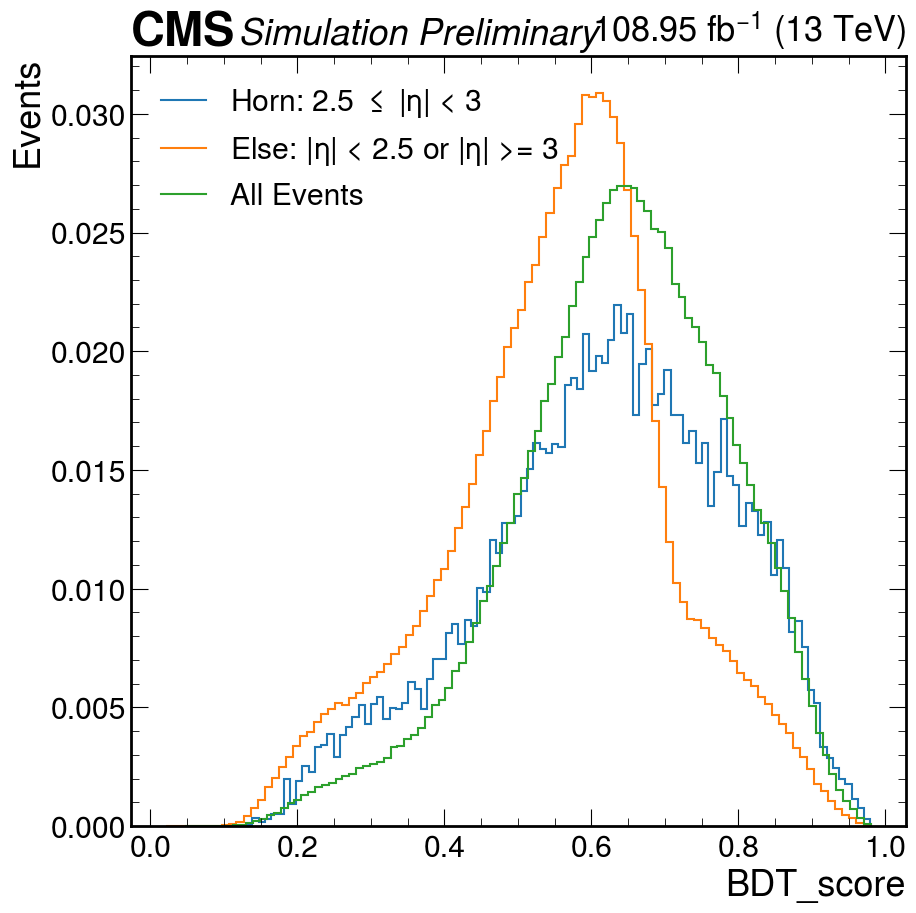

In [17]:
#Create a plot
fig, ax = plt.subplots()

# Plot a pre-binned histogram
hep.histplot(countsHorn_norm, bins=binsHorn, ax=ax, label="Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsNotHorn_norm, bins=binsNotHorn, ax=ax, label="Else: |$\eta$| < 2.5 or |$\eta$| >= 3")
hep.histplot(countsAll_norm, bins=binsAll, ax=ax, label="All Events")
# Add appropriate labels

hep.cms.label("Preliminary", data=False, lumi=108.95, com=13) # ax can be implicit
ax.legend()
#hep.mpl_magic()  # Autofit label - not needed

ax.set_xlabel('BDT_score')
ax.set_ylabel('Events')
#ax.set_title('Jet eta horn BDT score comparison')
plt.show()

Text(0, 1, 'Events')

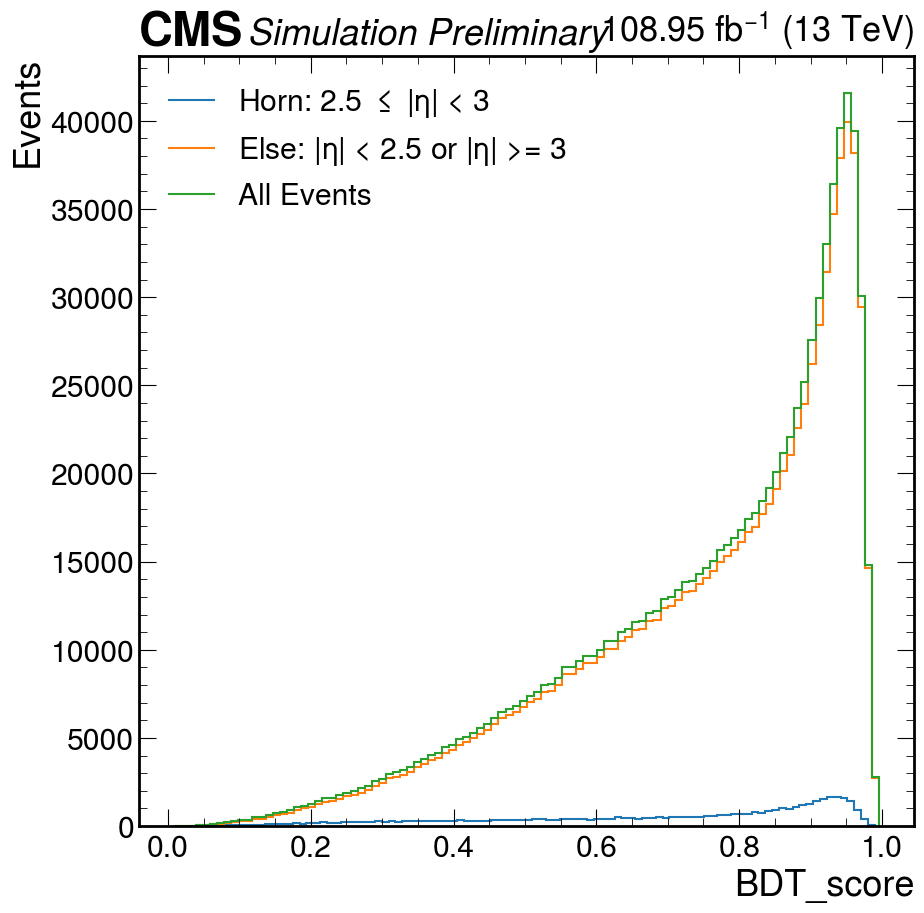

In [18]:
input_file = "../root_io/tuples/BDT_score/VBF/BFull_SNottH/VBF_2024_BFull_SNottH.root"
out_tree = ur.open(input_file+":tree_output")
BDT_VBF = out_tree["BDT_VBF"].array(library='np')
leading_jet_eta = out_tree["leading_jet_eta"].array(library='np')
subleading_jet_eta = out_tree["subleading_jet_eta"].array(library='np')
leading_jet_pt = out_tree["leading_jet_pt"].array(library='np')
subleading_jet_pt = out_tree["subleading_jet_pt"].array(library='np')

horn_mask = (np.abs(leading_jet_eta) >= 2.5) & (np.abs(leading_jet_eta) < 3) & (np.abs(subleading_jet_eta) >= 2.5) & (np.abs(subleading_jet_eta) < 3)
jet_mask = (leading_jet_eta != 0) & (subleading_jet_eta != 0) 

countsHorn, binsHorn = np.histogram(BDT_VBF[horn_mask], bins=100)
countsNotHorn, binsNotHorn = np.histogram(BDT_VBF[~horn_mask], bins=100)
countsAll, binsAll = np.histogram(BDT_VBF[jet_mask], bins=100)

#Create a plot
fig, ax = plt.subplots()

# Plot a pre-binned histogram
hep.histplot(countsHorn, bins=binsHorn, ax=ax, label="Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsNotHorn, bins=binsNotHorn, ax=ax, label="Else: |$\eta$| < 2.5 or |$\eta$| >= 3")
hep.histplot(countsAll, bins=binsAll, ax=ax, label="All Events")
# Add appropriate labels
hep.cms.label("Preliminary", data=False, lumi=108.95, com=13) # ax can be implicit
ax.legend()
#hep.mpl_magic()  # Autofit label - not needed

ax.set_xlabel('BDT_score')
ax.set_ylabel('Events')
#ax.set_title('Jet eta horn BDT score comparison')

In [19]:
def plot_BDT_with_mask(BDT_score, mask, allMask, title=""):
    countsMask, binsMask = np.histogram(BDT_score[mask], bins=100)
    countsNotMask, binsNotMask = np.histogram(BDT_score[~mask], bins=100)
    countsAll, binsAll = np.histogram(BDT_score[jet_mask], bins=100)

    #Create a plot
    fig, ax = plt.subplots()

    # Plot a pre-binned histogram
    hep.histplot(countsMask, bins=binsMask, ax=ax, label="Horn: 2.5 $\leq$ |$\eta$| < 3")
    hep.histplot(countsNotHorn, bins=binsNotHorn, ax=ax, label="Else: |$\eta$| < 2.5 or |$\eta$| >= 3")
    hep.histplot(countsAll, bins=binsAll, ax=ax, label="All Events")
    # Add appropriate labels
    hep.cms.label("Preliminary", data=False, lumi=108.95, com=13) # ax can be implicit
    ax.legend()
    #hep.mpl_magic()  # Autofit label - not needed

    ax.set_xlabel('BDT_score')
    ax.set_ylabel('Events')
    #ax.set_title('Jet eta horn BDT score comparison')

[0.0, 0.19152000000000016, 0.5472000000000005, 0.8550000000000006, 1.0]


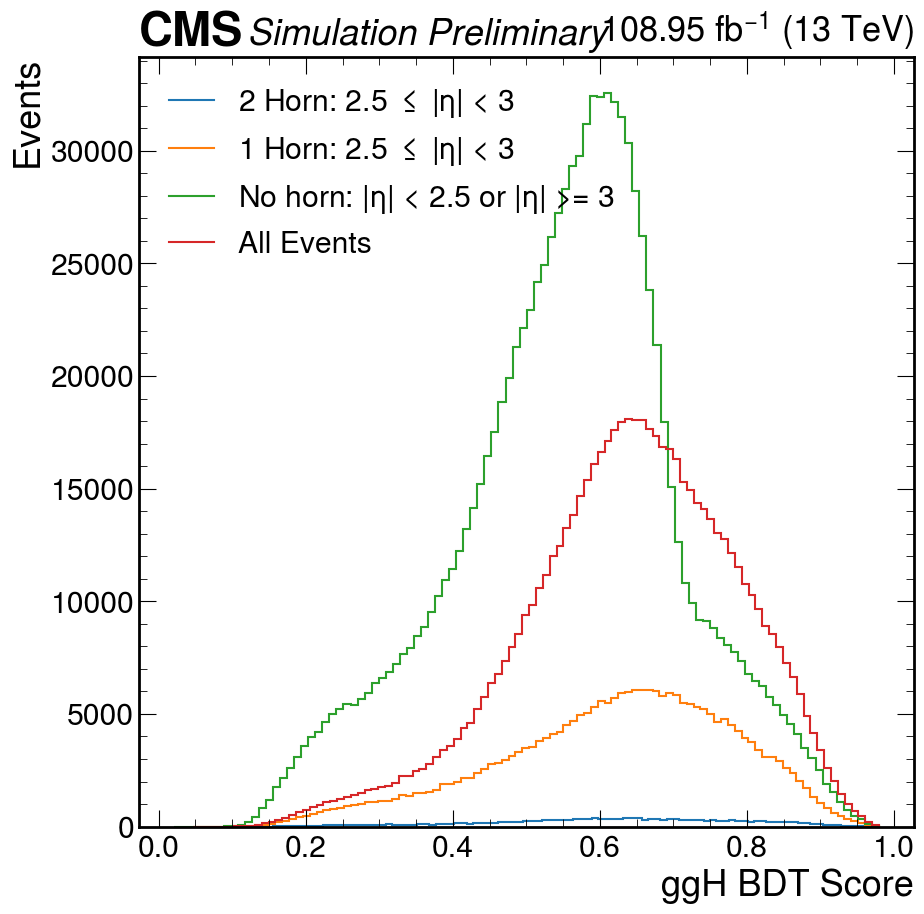

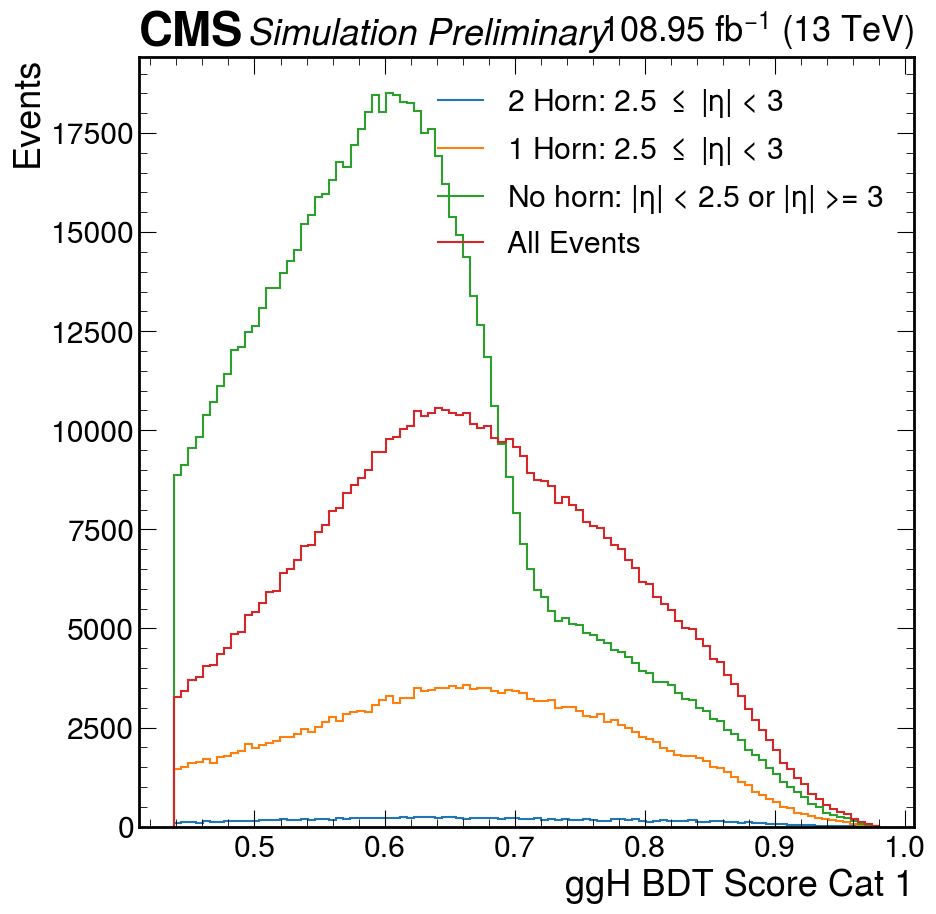

In [20]:
input_file = "../root_io/tuples/BDT_score/ggH/BFull_SNottH/ggH_2024_BFull_SNottH.root"
out_tree = ur.open(input_file+":tree_output")
BDT_ggH = out_tree["BDT_ggH"].array(library='np')
leading_jet_eta = out_tree["leading_jet_eta"].array(library='np')
subleading_jet_eta = out_tree["subleading_jet_eta"].array(library='np')
leading_jet_pt = out_tree["leading_jet_pt"].array(library='np')
subleading_jet_pt = out_tree["subleading_jet_pt"].array(library='np')

horn_mask = (np.abs(leading_jet_eta) >= 2.5) & (np.abs(leading_jet_eta) < 3) & (np.abs(subleading_jet_eta) >= 2.5) & (np.abs(subleading_jet_eta) < 3)
eitherHorn_mask = ((np.abs(leading_jet_eta) >= 2.5) & (np.abs(leading_jet_eta) < 3)) | ((np.abs(subleading_jet_eta) >= 2.5) & (np.abs(subleading_jet_eta) < 3))
jet_mask = leading_jet_eta != 0

bdt_selections = {
    "ggH": {
        "BFull_SNottH": [0.0, 0.19730769230769193, 0.4384615384615378, 1.0],

    },
    "VBF": {"BFull_SNottH":[0.0, 0.19152000000000016, 0.5472000000000005, 0.8550000000000006, 1.0],
    },
}

print(bdt_selections["VBF"]["BFull_SNottH"])

countsHorn, binsHorn = np.histogram(BDT_ggH[horn_mask], bins=100)
countsEitherHorn, binsEitherHorn = np.histogram(BDT_ggH[eitherHorn_mask], bins=100)
countsNotHorn, binsNotHorn = np.histogram(BDT_ggH[~eitherHorn_mask], bins=100)
countsAll, binsAll = np.histogram(BDT_ggH[jet_mask], bins=100)

countsHorncat1, binsHorncat1 = np.histogram(BDT_ggH[horn_mask][BDT_ggH[horn_mask] > bdt_selections["ggH"]["BFull_SNottH"][-2]], bins=100)
countsEitherHorncat1, binsEitherHorncat1 = np.histogram(BDT_ggH[eitherHorn_mask][BDT_ggH[eitherHorn_mask] > bdt_selections["ggH"]["BFull_SNottH"][-2]], bins=100)
countsNotHorncat1, binsNotHorncat1 = np.histogram(BDT_ggH[~eitherHorn_mask][BDT_ggH[~eitherHorn_mask] > bdt_selections["ggH"]["BFull_SNottH"][-2]], bins=100)
countsAllcat1, binsAllcat1 = np.histogram(BDT_ggH[jet_mask][BDT_ggH[jet_mask] > bdt_selections["ggH"]["BFull_SNottH"][-2]], bins=100)


#Create a plot
fig, ax = plt.subplots()

# Plot a pre-binned histogram
hep.histplot(countsHorn, bins=binsHorn, ax=ax, label="2 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsEitherHorn, bins=binsEitherHorn, ax=ax, label="1 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsNotHorn, bins=binsNotHorn, ax=ax, label="No horn: |$\eta$| < 2.5 or |$\eta$| >= 3")
hep.histplot(countsAll, bins=binsAll, ax=ax, label="All Events")
# Add appropriate labels
hep.cms.label("Preliminary", data=False, lumi=108.95, com=13) # ax can be implicit
ax.legend()
#hep.mpl_magic()  # Autofit label - not needed

ax.set_xlabel('ggH BDT Score')
ax.set_ylabel('Events')
#ax.set_title('Jet eta horn BDT score comparison')
plt.savefig('../plots/BDT_score/ggH_BDT_score_all.png')

plt.show()

fig, ax = plt.subplots()

# Plot a pre-binned histogram
hep.histplot(countsHorncat1, bins=binsHorncat1, ax=ax, label="2 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsEitherHorncat1, bins=binsEitherHorncat1, ax=ax, label="1 Horn: 2.5 $\leq$ |$\eta$| < 3")
hep.histplot(countsNotHorncat1, bins=binsNotHorncat1, ax=ax, label="No horn: |$\eta$| < 2.5 or |$\eta$| >= 3")
hep.histplot(countsAllcat1, bins=binsAllcat1, ax=ax, label="All Events")
# Add appropriate labels
hep.cms.label("Preliminary", data=False, lumi=108.95, com=13) # ax can be implicit
ax.legend()
#hep.mpl_magic()  # Autofit label - not needed

ax.set_xlabel('ggH BDT Score Cat 1')
ax.set_ylabel('Events')
#ax.set_title('Jet eta horn BDT score comparison')
plt.savefig('../plots/BDT_score/ggH_BDT_score_cat1.png')


In [36]:
#def plot_BDT_by_eta_horn_count_and_category(inputFile, BDT_selections, category='ggH', ifNorm=False, ifSave=False):
def plot_BDT_by_eta_horn_count_and_category(category='ggH', signal='ggH', era="2024", BDT_selections=None, ifNorm=False, ifSave=False):
    inputFile = "../root_io/tuples/BDT_score/" + category + "/BFull_SNottH/" + signal + "_" + era + "_BFull_SNottH.root"
    out_tree = ur.open(inputFile+":tree_output")
    
    BDT_score = out_tree["BDT_" + category].array(library='np')
        
    leading_jet_eta = out_tree["leading_jet_eta"].array(library='np')
    subleading_jet_eta = out_tree["subleading_jet_eta"].array(library='np')
    
    two_horn_mask = (np.abs(leading_jet_eta) >= 2.5) & (np.abs(leading_jet_eta) < 3) & (np.abs(subleading_jet_eta) >= 2.5) & (np.abs(subleading_jet_eta) < 3)
    one_horn_mask = ((np.abs(leading_jet_eta) >= 2.5) & (np.abs(leading_jet_eta) < 3)) ^ ((np.abs(subleading_jet_eta) >= 2.5) & (np.abs(subleading_jet_eta) < 3))
    a_horn_mask = ((np.abs(leading_jet_eta) >= 2.5) & (np.abs(leading_jet_eta) < 3)) | ((np.abs(subleading_jet_eta) >= 2.5) & (np.abs(subleading_jet_eta) < 3))

    #print(len(bdt_selections[category]["BFull_SNottH"]))
    for i in range(0,len(bdt_selections[category]["BFull_SNottH"])):
        if (i != len(bdt_selections[category]["BFull_SNottH"]) - 1):
            if(ifNorm):
                continue
            countsTwoHorn, binsTwoHorn = np.histogram(BDT_score[two_horn_mask][(BDT_score[two_horn_mask] > bdt_selections[category]["BFull_SNottH"][i]) & (BDT_score[two_horn_mask] < bdt_selections[category]["BFull_SNottH"][i+1])], bins=100)
            countsOneHorn, binsOneHorn = np.histogram(BDT_score[one_horn_mask][(BDT_score[one_horn_mask] > bdt_selections[category]["BFull_SNottH"][i]) & (BDT_score[one_horn_mask] < bdt_selections[category]["BFull_SNottH"][i+1])], bins=100)
            countsNoHorn, binsNoHorn = np.histogram(BDT_score[~a_horn_mask][(BDT_score[~a_horn_mask] > bdt_selections[category]["BFull_SNottH"][i]) & (BDT_score[~a_horn_mask] < bdt_selections[category]["BFull_SNottH"][i+1])], bins=100)
            countsAll, binsAll = np.histogram(BDT_score[(BDT_score > bdt_selections[category]["BFull_SNottH"][i]) & (BDT_score < bdt_selections[category]["BFull_SNottH"][i+1])], bins=100)
            bdtCat = "Cat" + str(len(bdt_selections[category]["BFull_SNottH"]) - 1 - i)
            
        else:
            countsTwoHorn, binsTwoHorn = np.histogram(BDT_score[two_horn_mask], bins=100)
            countsOneHorn, binsOneHorn = np.histogram(BDT_score[one_horn_mask], bins=100)
            countsNoHorn, binsNoHorn = np.histogram(BDT_score[~a_horn_mask], bins=100)
            countsAll, binsAll = np.histogram(BDT_score, bins=100)
            bdtCat = "AllCats"

        if ifNorm:
            countsTwoHorn = countsTwoHorn / countsTwoHorn.sum()
            countsOneHorn = countsOneHorn / countsOneHorn.sum()
            countsNoHorn = countsNoHorn / countsNoHorn.sum()
            countsAll = countsAll / countsAll.sum()


        per2Horn = countsTwoHorn.sum()/countsAll.sum() *100
        per1Horn = countsOneHorn.sum()/countsAll.sum() *100
        per0Horn = countsNoHorn.sum()/countsAll.sum() *100

        #Create a plot
        fig, ax = plt.subplots()

        # Plot a pre-binned histogram
        if ifNorm:
            hep.histplot(countsTwoHorn, bins=binsTwoHorn, ax=ax, label="2 Horn: 2.5 $\leq$ |$\eta$| < 3")
            hep.histplot(countsOneHorn, bins=binsOneHorn, ax=ax, label="1 Horn: 2.5 $\leq$ |$\eta$| < 3")
            hep.histplot(countsNoHorn, bins=binsNoHorn, ax=ax, label="No horn: |$\eta$| < 2.5 or |$\eta$| >= 3")
            hep.histplot(countsAll, bins=binsAll, ax=ax, label="All Events")
        else:    
            hep.histplot(countsTwoHorn, bins=binsTwoHorn, ax=ax, label="2 Horn: 2.5 $\leq$ |$\eta$| < 3: {:.2f}%".format(per2Horn))
            hep.histplot(countsOneHorn, bins=binsOneHorn, ax=ax, label="1 Horn: 2.5 $\leq$ |$\eta$| < 3: {:.2f}%".format(per1Horn))
            hep.histplot(countsNoHorn, bins=binsNoHorn, ax=ax, label="No horn: |$\eta$| < 2.5 or |$\eta$| >= 3: {:.2f}%".format(per0Horn))
            hep.histplot(countsAll, bins=binsAll, ax=ax, label="All Events")
        # Add appropriate labels
        hep.cms.label("Prelim", data=False, lumi=luminosity[era], com=13) # ax can be implicit
        ax.legend(loc=2)
        #hep.mpl_magic()  # Autofit label - not needed

        ax.set_xlabel(category + ' flag ' + signal + ' MC' + ' BDT Score ' + bdtCat)
        ax.set_ylabel('Events')
        #ax.set_title('Jet eta horn BDT score comparison')


        #set category lines
        if (i == len(bdt_selections[category]["BFull_SNottH"]) - 1):
            for categoryVal in bdt_selections[category]["BFull_SNottH"][1:-1]:
                ax.axvline(categoryVal, linestyle="--", linewidth=1, color='gray')

        if ifSave:
            name="../plots/BDT_score/" + category + "_flag_" + signal + "_MC_BDT_score_" + bdtCat
            if ifNorm:
                name += "_normed"
            name += ".png"
            #print(name)
            plt.savefig(name)
        plt.show()

        #if not ifNorm:
         #   print(signal + " events in " + category + " flagged events: {}".format(countsAll.sum()))'''

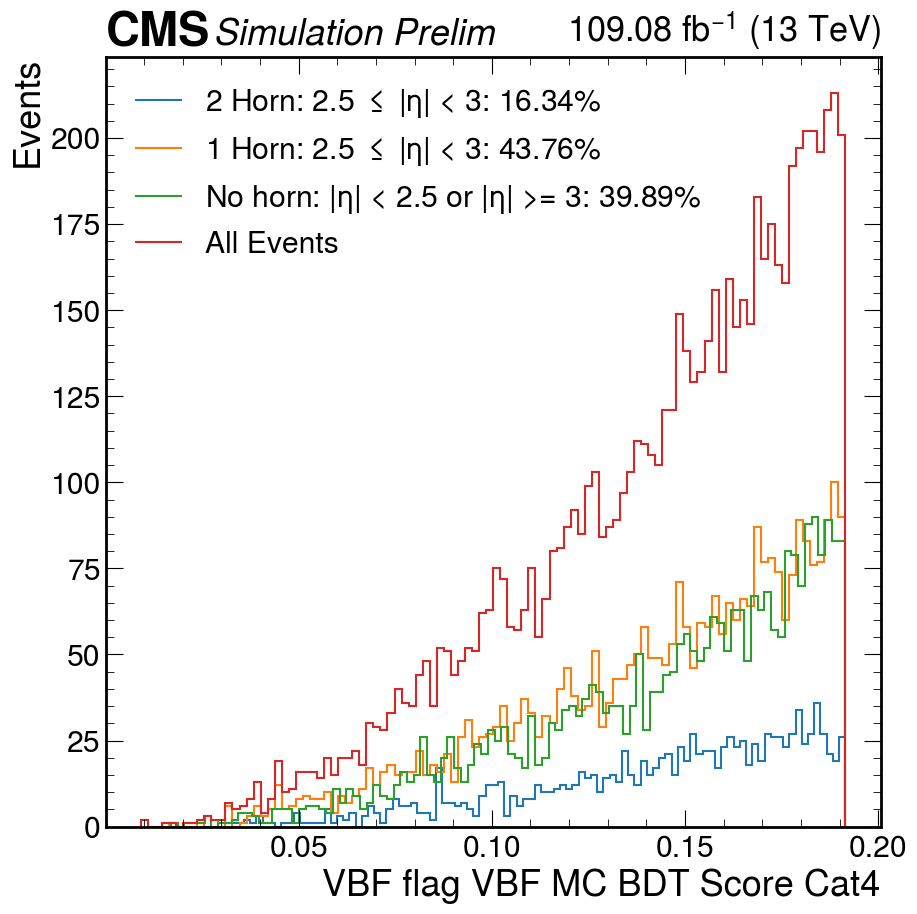

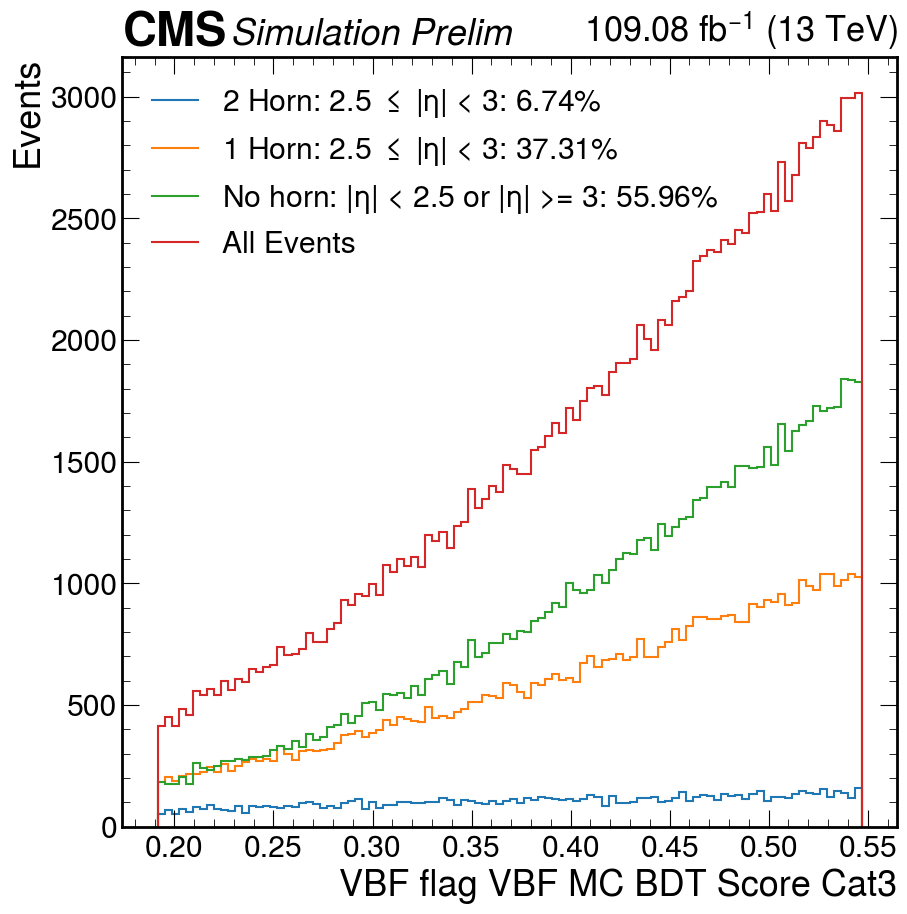

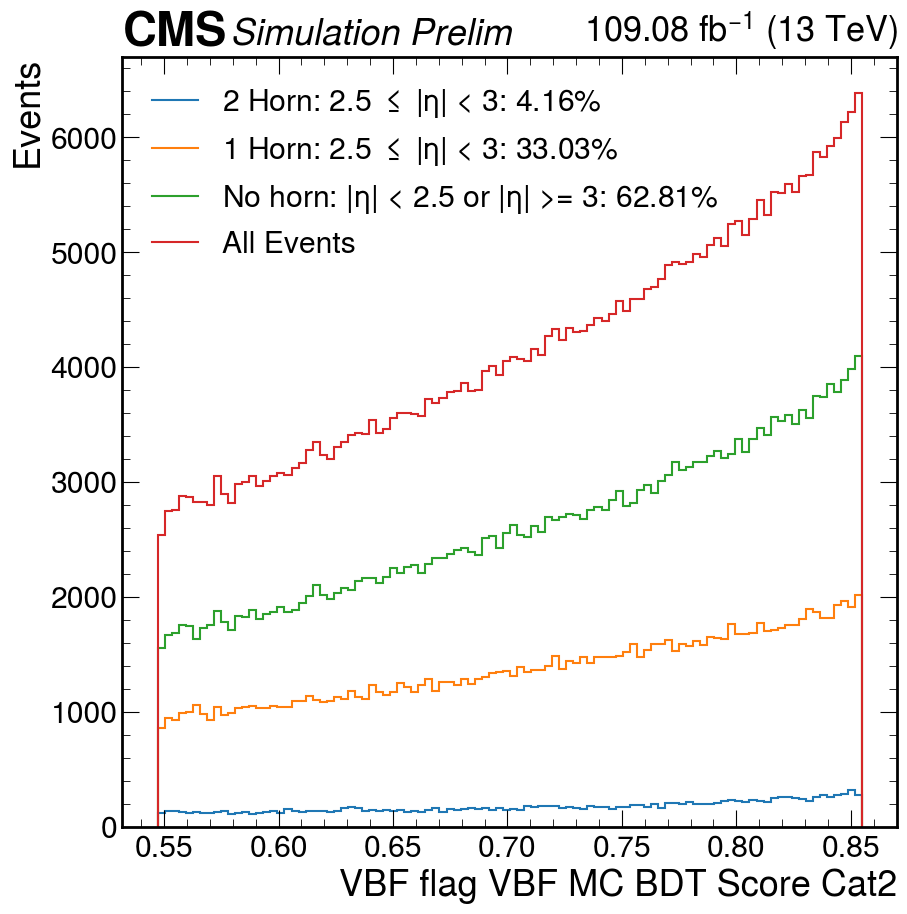

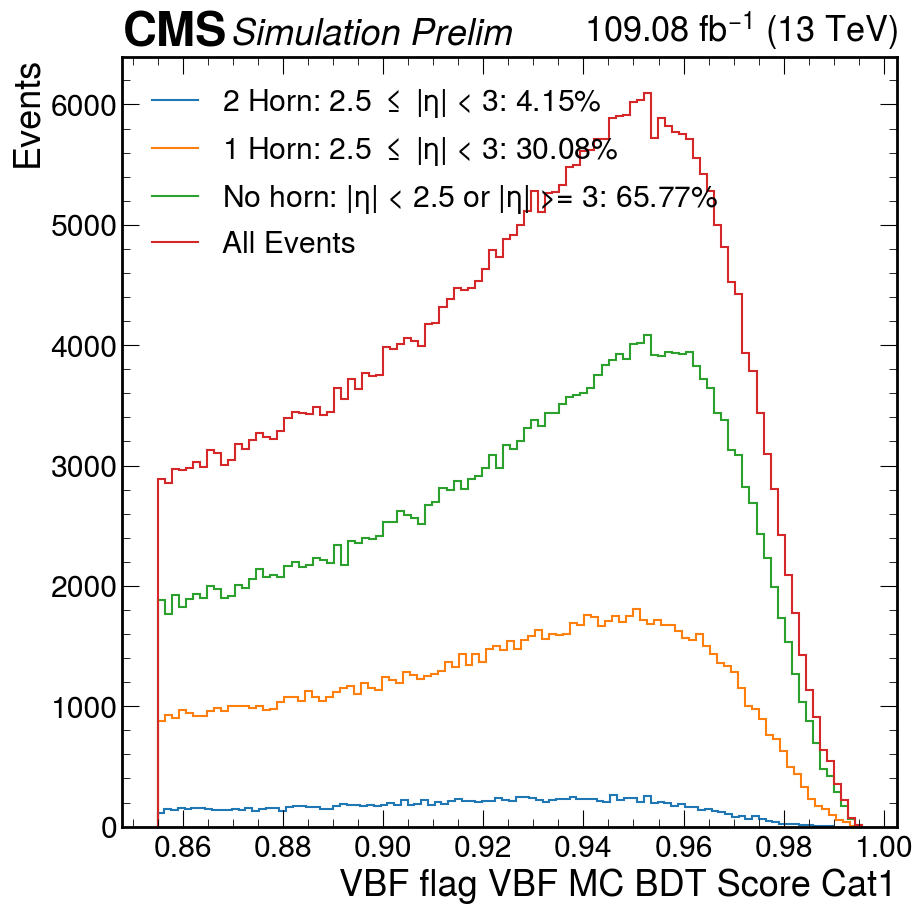

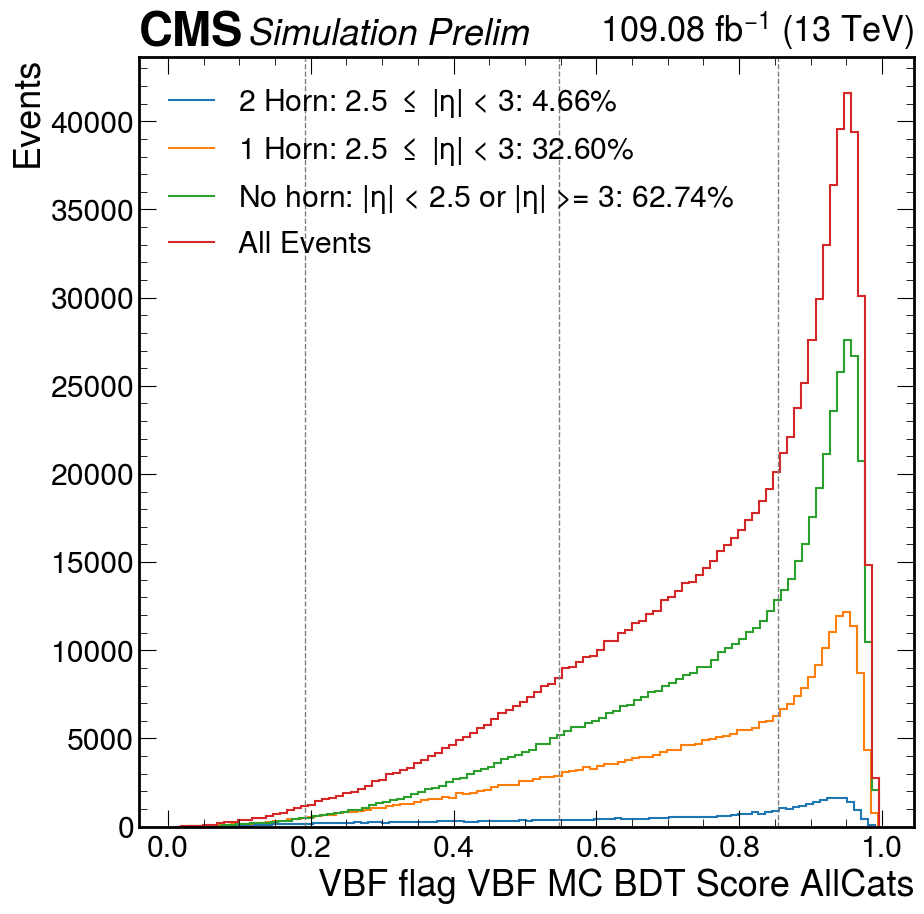

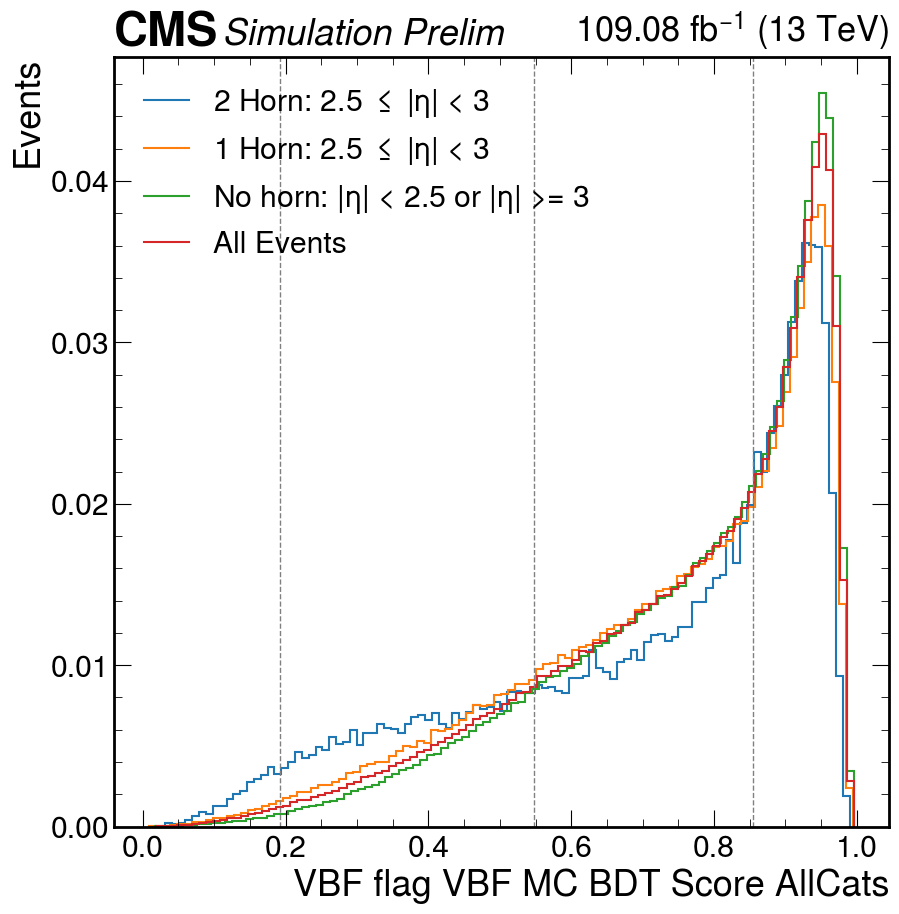

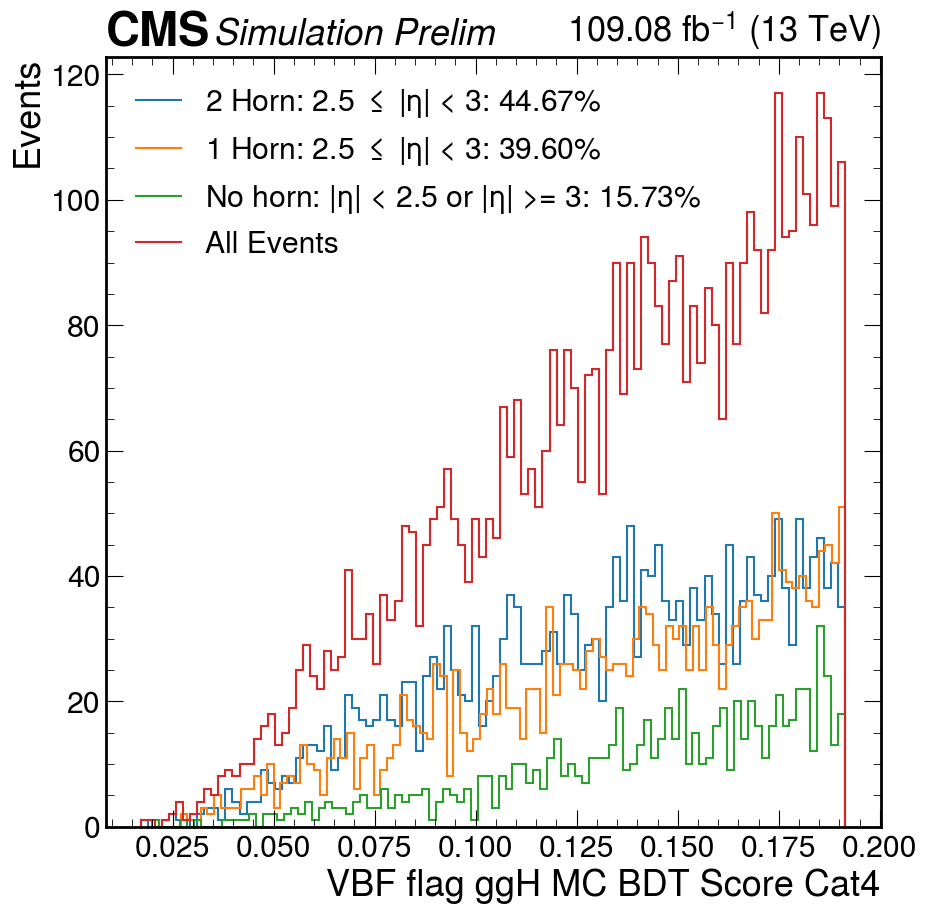

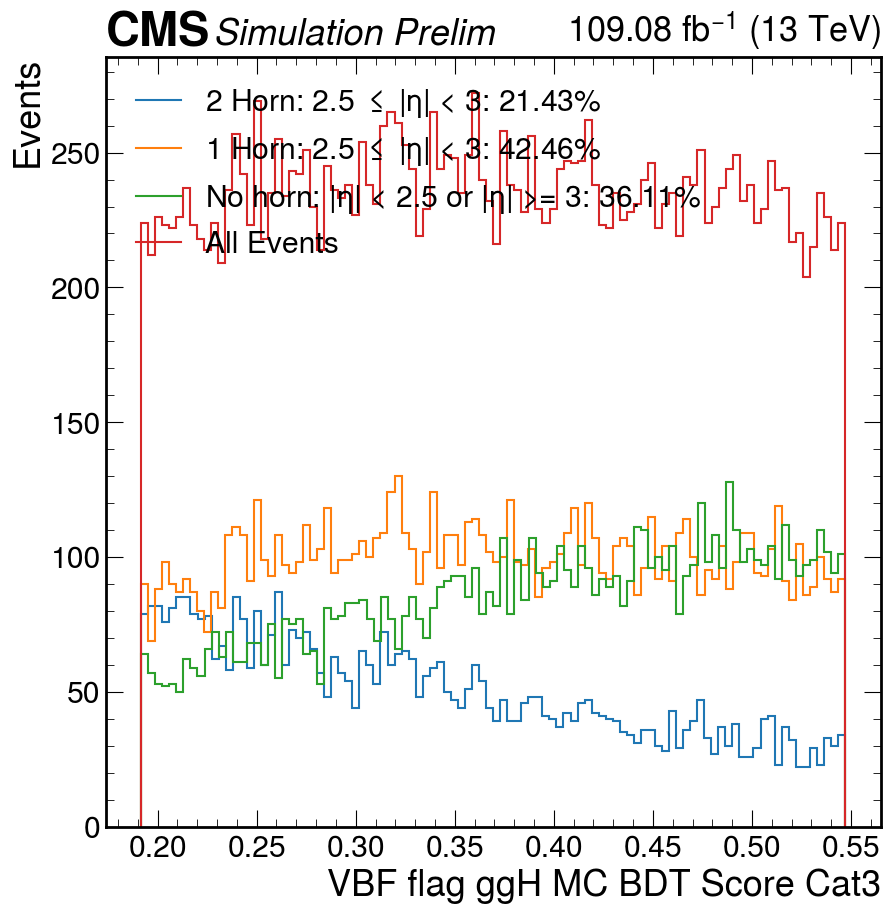

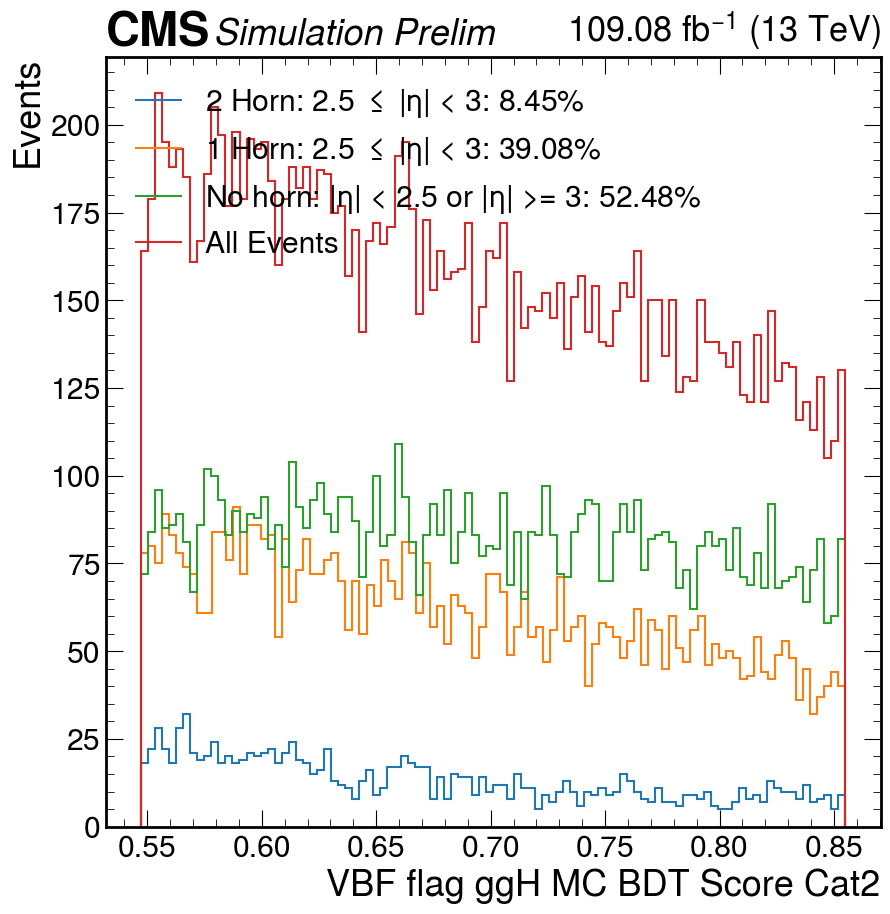

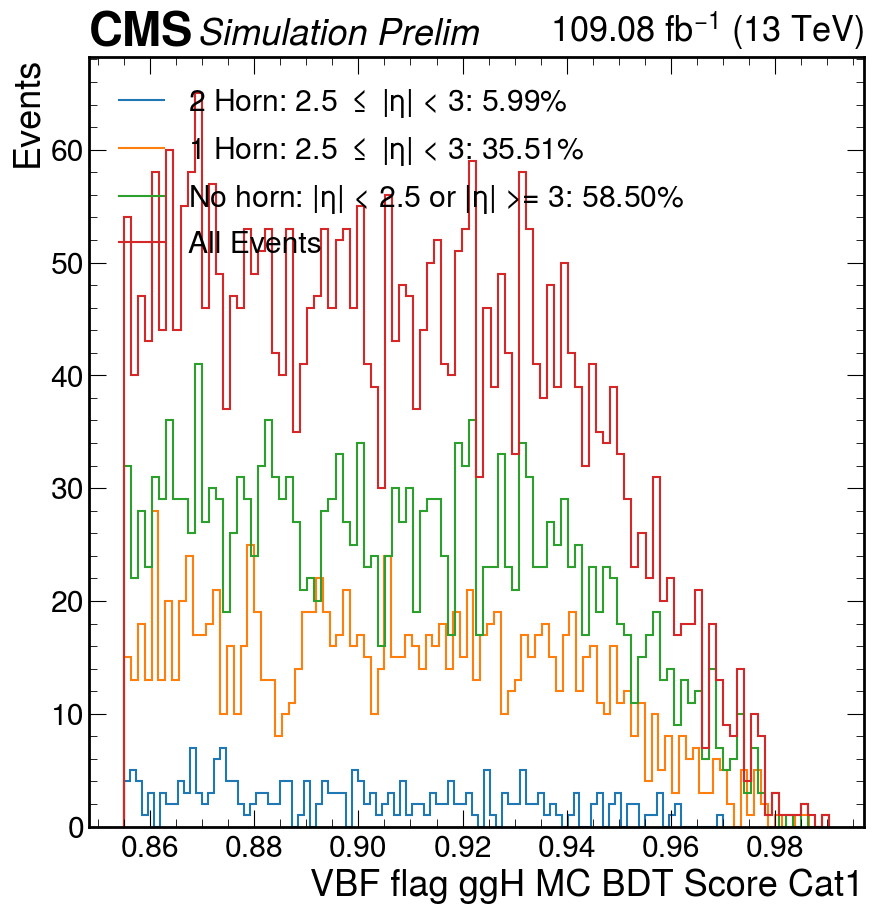

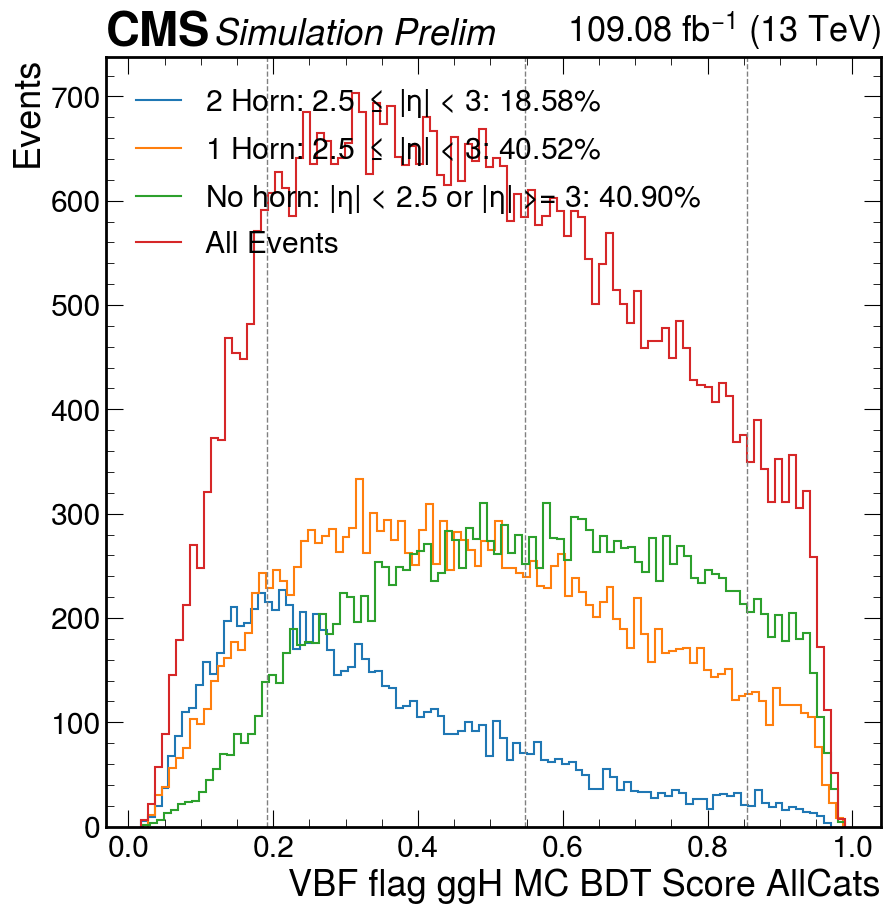

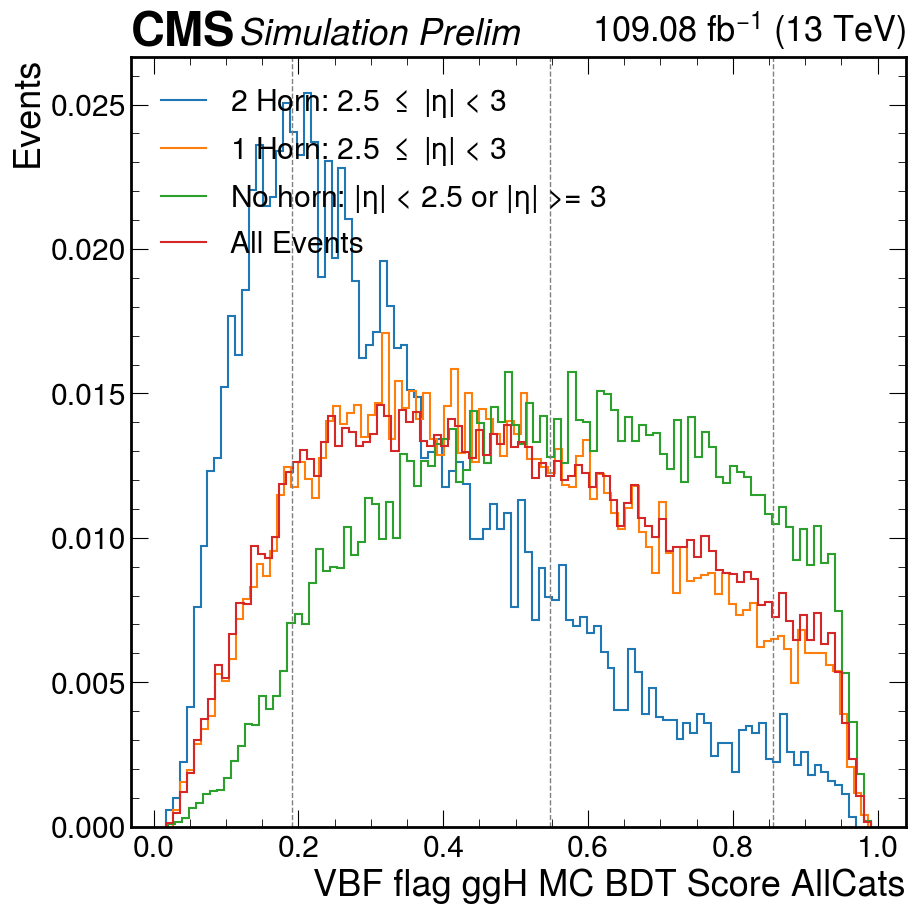

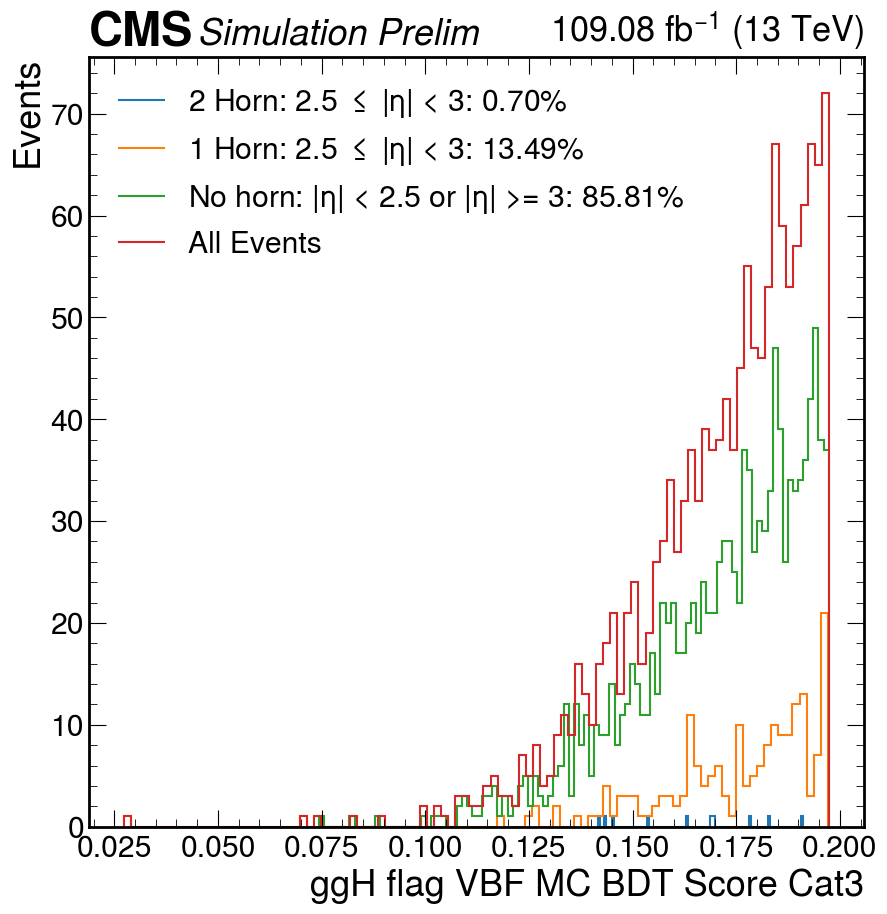

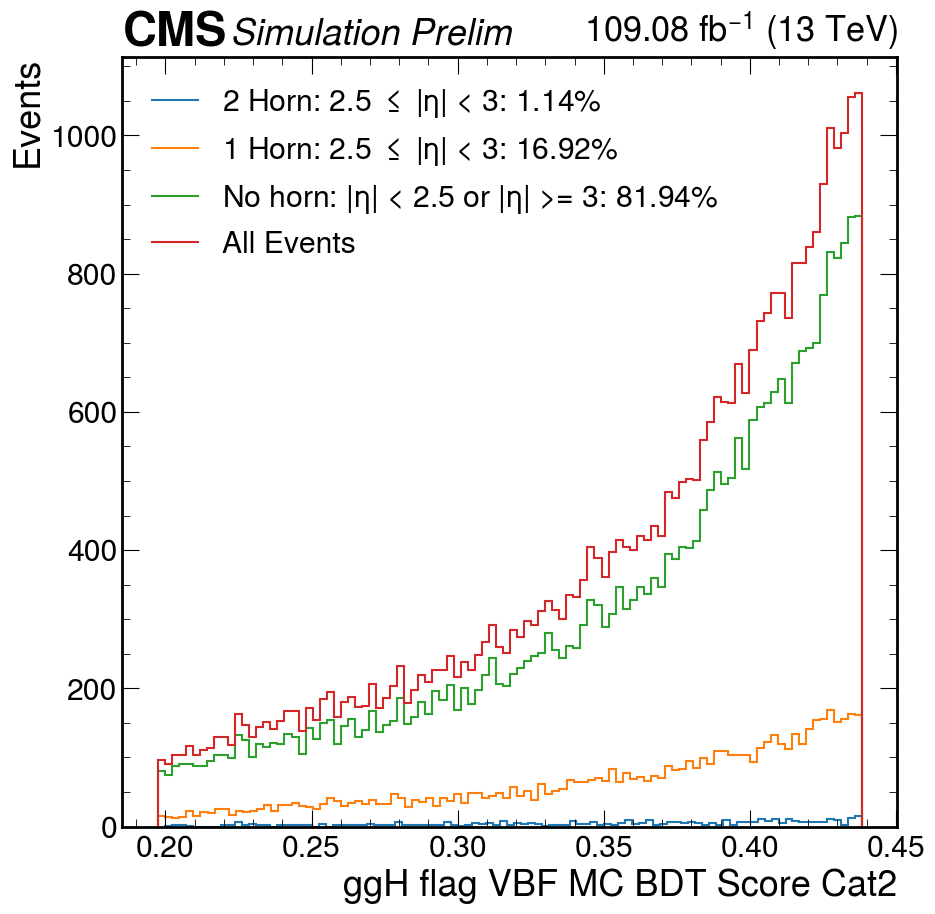

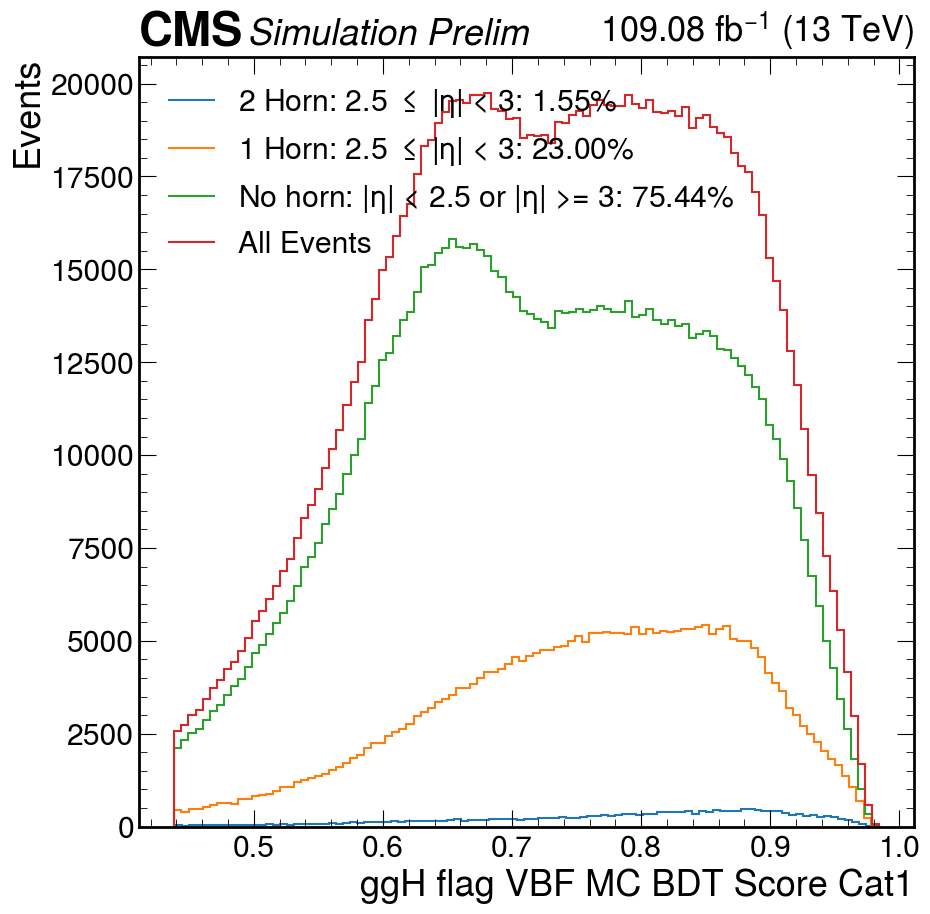

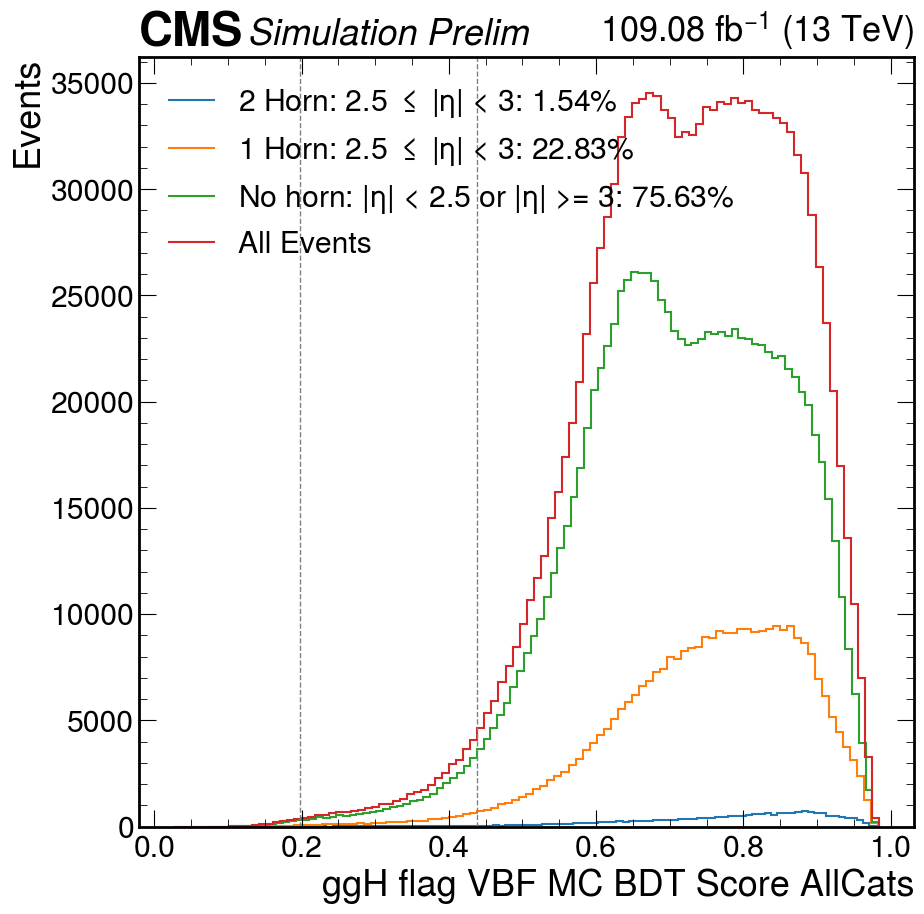

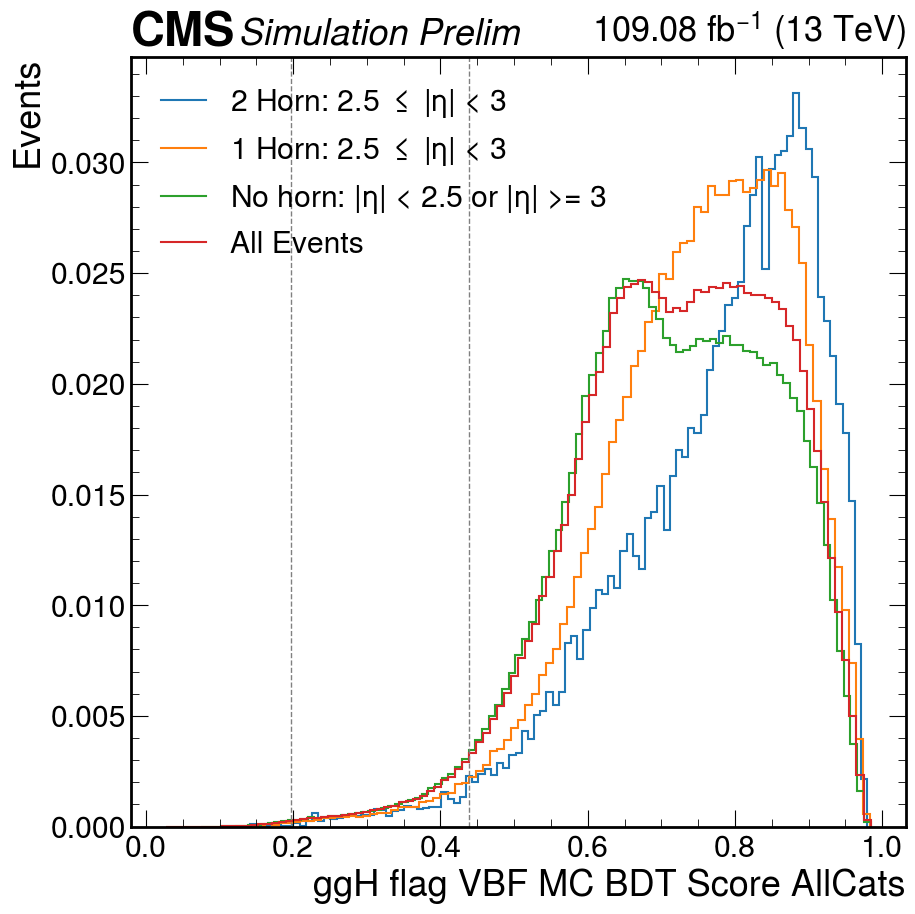

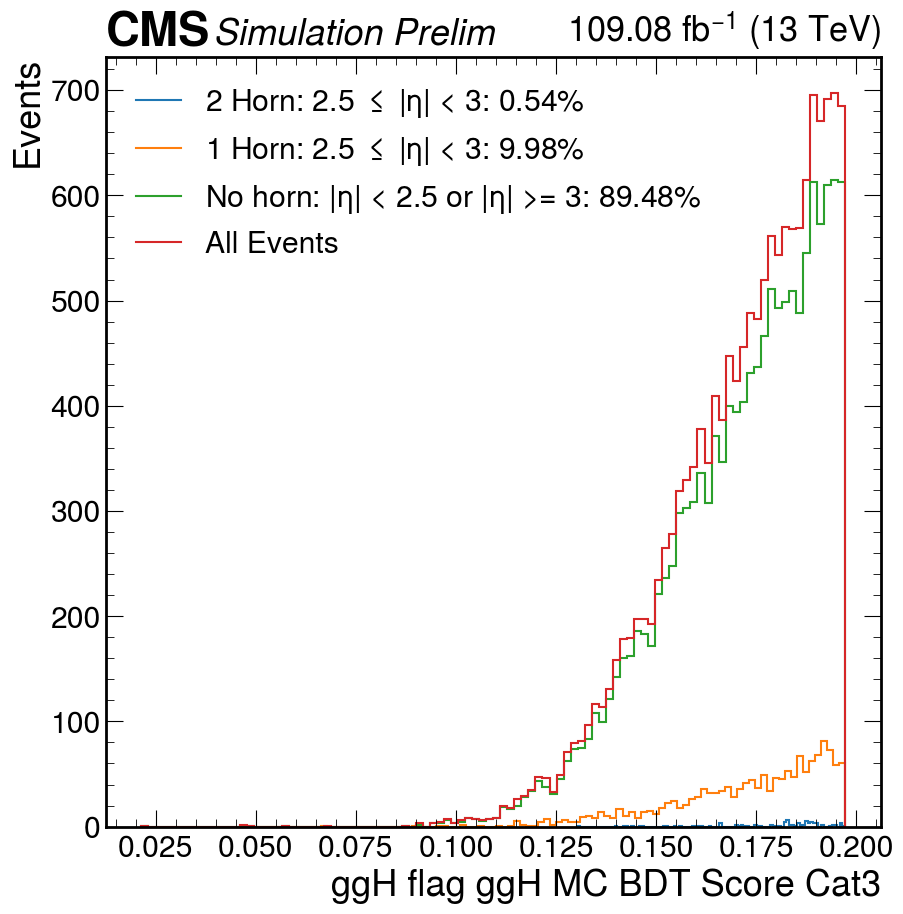

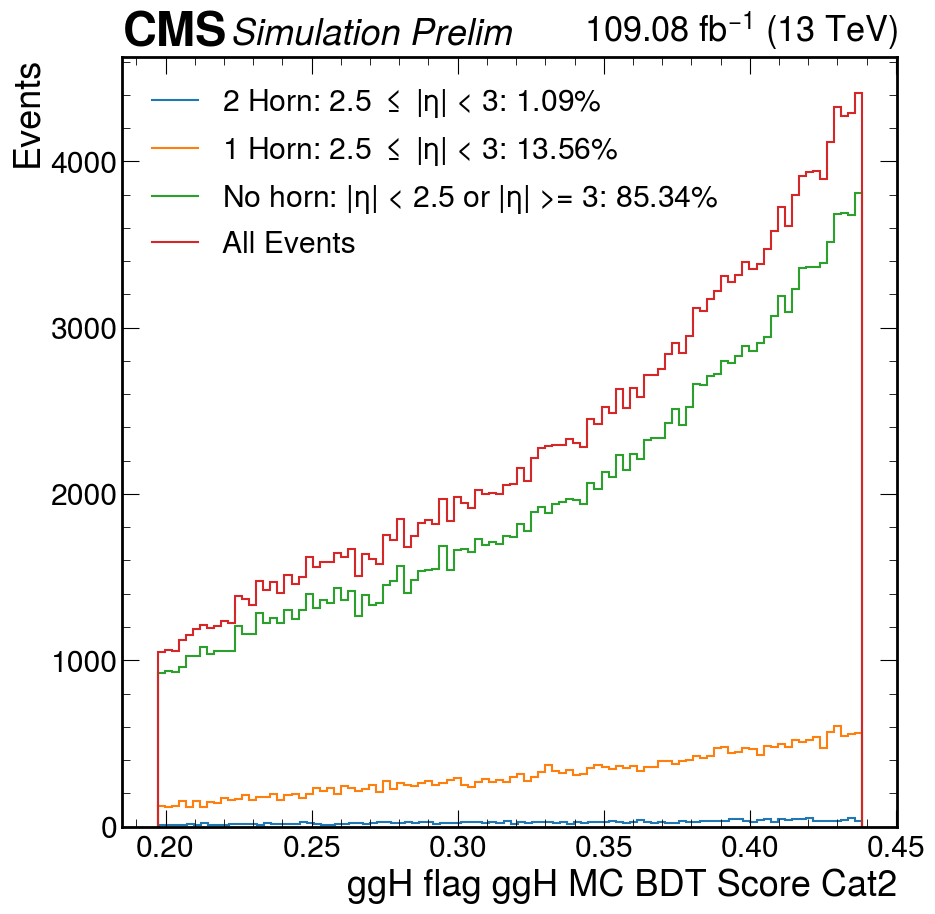

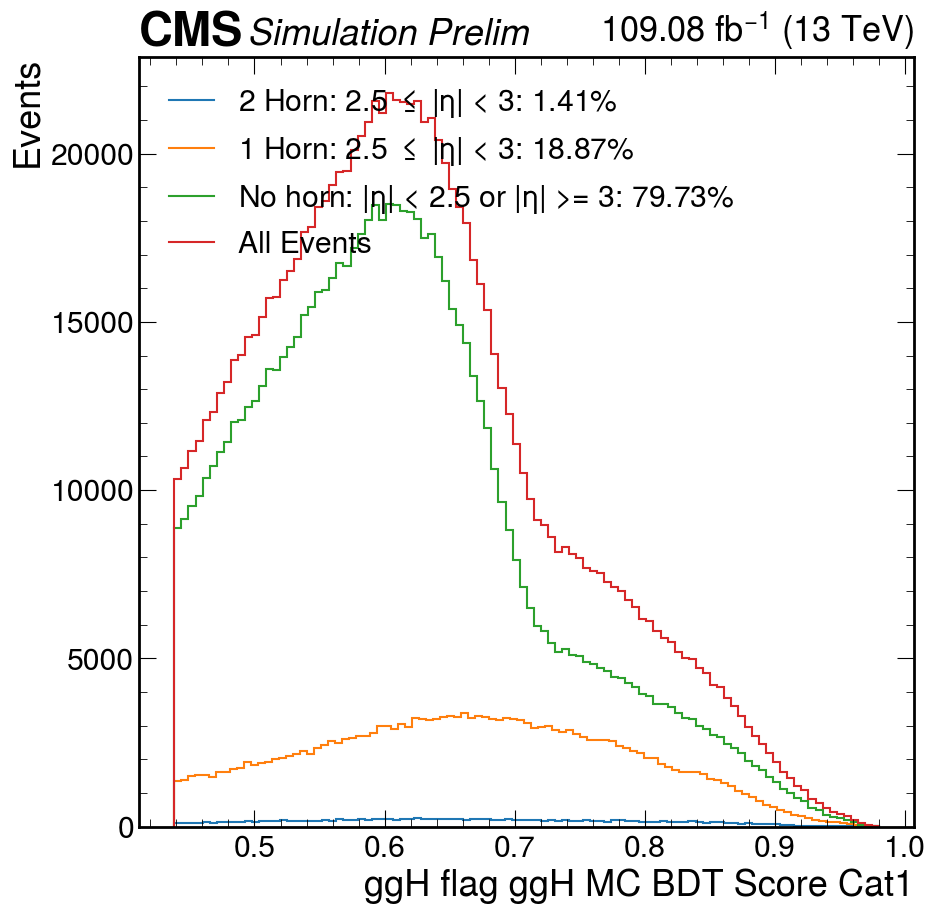

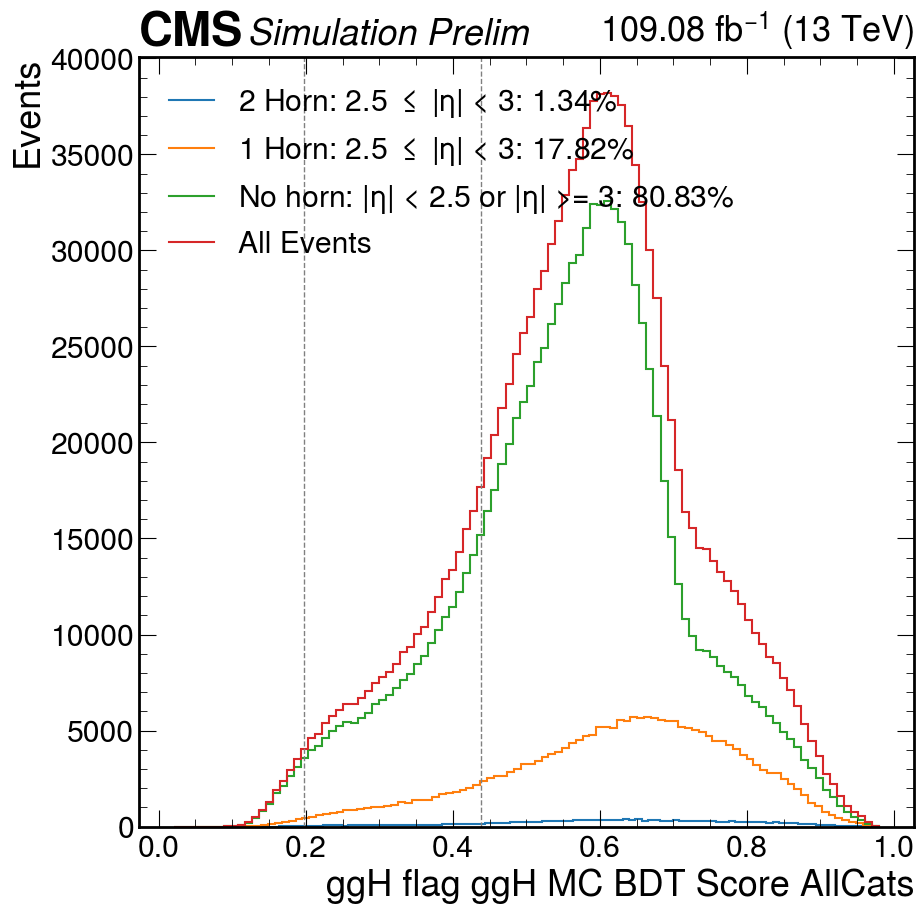

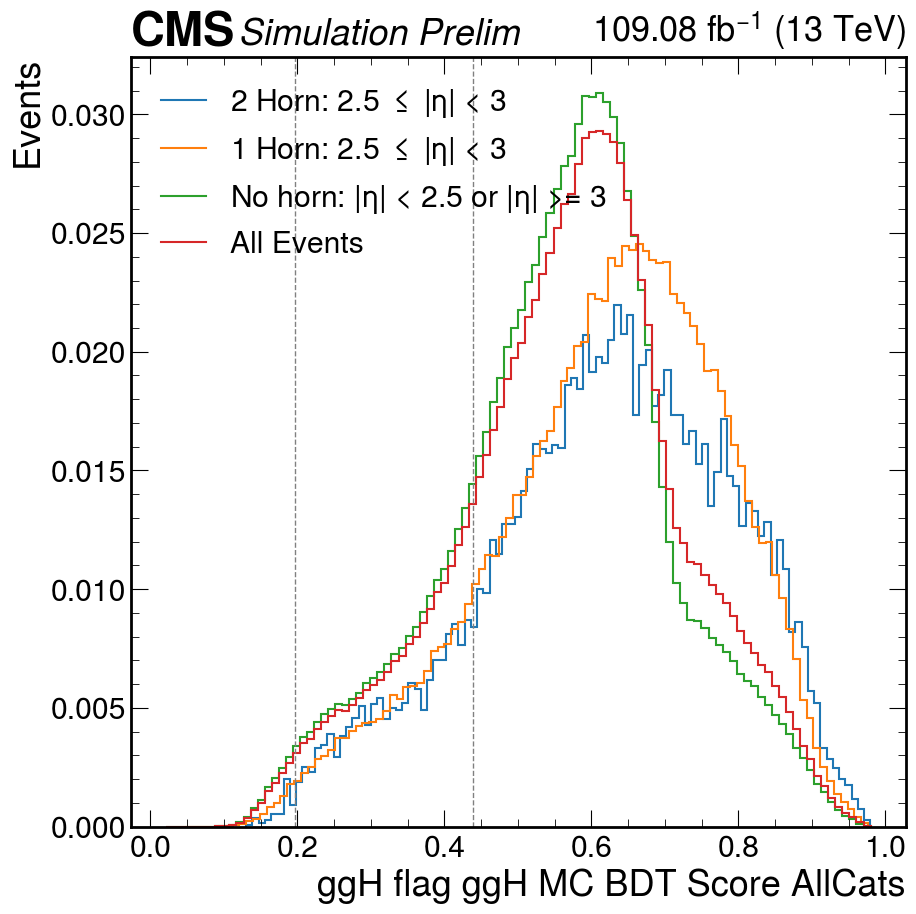

In [38]:
bdt_selections = {
    "ggH": {
        "BFull_SNottH": [0.0, 0.19730769230769193, 0.4384615384615378, 1.0],

    },
    "VBF": {"BFull_SNottH":[0.0, 0.19152000000000016, 0.5472000000000005, 0.8550000000000006, 1.0],
    },
}

plot_BDT_by_eta_horn_count_and_category(category='VBF', signal='VBF', era="2024", BDT_selections=bdt_selections, ifNorm=False, ifSave=True)
plot_BDT_by_eta_horn_count_and_category(category='VBF', signal='VBF', era="2024", BDT_selections=bdt_selections, ifNorm=True, ifSave=True)
plot_BDT_by_eta_horn_count_and_category(category='VBF', signal='ggH', era="2024", BDT_selections=bdt_selections, ifNorm=False, ifSave=True)
plot_BDT_by_eta_horn_count_and_category(category='VBF', signal='ggH', era="2024", BDT_selections=bdt_selections, ifNorm=True, ifSave=True)

plot_BDT_by_eta_horn_count_and_category(category='ggH', signal='VBF', era="2024", BDT_selections=bdt_selections, ifNorm=False, ifSave=True)
plot_BDT_by_eta_horn_count_and_category(category='ggH', signal='VBF', era="2024", BDT_selections=bdt_selections, ifNorm=True, ifSave=True)
plot_BDT_by_eta_horn_count_and_category(category='ggH', signal='ggH', era="2024", BDT_selections=bdt_selections, ifNorm=False, ifSave=True)
plot_BDT_by_eta_horn_count_and_category(category='ggH', signal='ggH', era="2024", BDT_selections=bdt_selections, ifNorm=True, ifSave=True)

In [35]:
print(len(bdt_selections["ggH"]["BFull_SNottH"]) - 1)

3
